In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cole's code 
## simulate data based on race

FARA = pd.read_csv ('../data/FARA.csv')
FARA = FARA[FARA['State'] == 'Arizona']
PLACES2020 = pd.read_csv('../data/PLACES2020.csv')
PLACES2020 = PLACES2020[PLACES2020['StateAbbr'] == 'AZ']
Columns_to_extract = ['CensusTract','TractWhite','TractBlack','TractAsian','TractNHOPI','TractAIAN','TractOMultir','TractHispanic']
PLACES_Columns_to_extract = ['OBESITY_CrudePrev','DIABETES_CrudePrev','TractFIPS','CountyName']
PLACES2020_Race = PLACES2020[PLACES_Columns_to_extract]
PLACES2020_Race
FARA_IMP = FARA[Columns_to_extract]
FARA_IMP = FARA_IMP.rename(columns = {'CensusTract' : 'TractFIPS'})
FARA_IMP = FARA_IMP.groupby('TractFIPS').sum()
Merged_By_Race = pd.merge(PLACES2020_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race['WhiteDiabetes'] = Merged_By_Race['TractWhite'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['WhiteObesity'] = Merged_By_Race['TractWhite'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['WhiteNoDiabetes'] = Merged_By_Race['TractWhite'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['WhiteNoObesity'] = Merged_By_Race['TractWhite'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['BlackDiabetes'] = Merged_By_Race['TractBlack'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['BlackObesity'] = Merged_By_Race['TractBlack'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['BlackNoDiabetes'] = Merged_By_Race['TractBlack'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['BlackNoObesity'] = Merged_By_Race['TractBlack'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['AsianDiabetes'] = Merged_By_Race['TractAsian'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['AsianObesity'] = Merged_By_Race['TractAsian'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['AsianNoDiabetes'] = Merged_By_Race['TractAsian'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['AsianNoObesity'] = Merged_By_Race['TractAsian'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['NHOPIDiabetes'] = Merged_By_Race['TractNHOPI'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['NHOPIObesity'] = Merged_By_Race['TractNHOPI'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['NHOPINoDiabetes'] = Merged_By_Race['TractNHOPI'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['NHOPINoObesity'] = Merged_By_Race['TractNHOPI'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['AIANDiabetes'] = Merged_By_Race['TractAIAN'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['AIANObesity'] = Merged_By_Race['TractAIAN'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['AIANNoDiabetes'] = Merged_By_Race['TractAIAN'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['AIANNoObesity'] = Merged_By_Race['TractAIAN'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['OMultirDiabetes'] = Merged_By_Race['TractOMultir'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['OMultirObesity'] = Merged_By_Race['TractOMultir'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['OMultirNoDiabetes'] = Merged_By_Race['TractOMultir'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['OMultirNoObesity'] = Merged_By_Race['TractOMultir'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race['HispanicDiabetes'] = Merged_By_Race['TractHispanic'] * Merged_By_Race['DIABETES_CrudePrev']/100
Merged_By_Race['HispanicObesity'] = Merged_By_Race['TractHispanic'] * Merged_By_Race['OBESITY_CrudePrev']/100
Merged_By_Race['HispanicNoDiabetes'] = Merged_By_Race['TractHispanic'] * (100-Merged_By_Race['DIABETES_CrudePrev'])/100
Merged_By_Race['HispanicNoObesity'] = Merged_By_Race['TractHispanic'] * (100-Merged_By_Race['OBESITY_CrudePrev'])/100
Merged_By_Race = Merged_By_Race.groupby('CountyName').sum()
Merged_By_Race['%WhiteDiabetes'] = Merged_By_Race['WhiteDiabetes']/Merged_By_Race['TractWhite']
Merged_By_Race['%WhiteObesity'] = Merged_By_Race['WhiteObesity']/Merged_By_Race['TractWhite']
Merged_By_Race['%BlackDiabetes'] = Merged_By_Race['BlackDiabetes']/Merged_By_Race['TractBlack']
Merged_By_Race['%BlackObesity'] = Merged_By_Race['BlackObesity']/Merged_By_Race['TractBlack']
Merged_By_Race['%AsianDiabetes'] = Merged_By_Race['AsianDiabetes']/Merged_By_Race['TractAsian']
Merged_By_Race['%AsianObesity'] = Merged_By_Race['AsianObesity']/Merged_By_Race['TractAsian']
Merged_By_Race['%NHOPIDiabetes'] = Merged_By_Race['NHOPIDiabetes']/Merged_By_Race['TractNHOPI']
Merged_By_Race['%NHOPIObesity'] = Merged_By_Race['NHOPIObesity']/Merged_By_Race['TractNHOPI']
Merged_By_Race['%AIANDiabetes'] = Merged_By_Race['AIANDiabetes']/Merged_By_Race['TractAIAN']
Merged_By_Race['%AIANObesity'] = Merged_By_Race['AIANObesity']/Merged_By_Race['TractAIAN']
Merged_By_Race['%OMultirDiabetes'] = Merged_By_Race['OMultirDiabetes']/Merged_By_Race['TractOMultir']
Merged_By_Race['%OMultirObesity'] = Merged_By_Race['OMultirObesity']/Merged_By_Race['TractOMultir']
Merged_By_Race['%HispanicDiabetes'] = Merged_By_Race['HispanicDiabetes']/Merged_By_Race['TractHispanic']
Merged_By_Race['%HispanicObesity'] = Merged_By_Race['HispanicObesity']/Merged_By_Race['TractHispanic']
Merged_By_Race['year'] = '2018'
Merged_By_Race



PLACES2021 = pd.read_csv('../data/PLACES2021.csv')
PLACES2021 = PLACES2021[PLACES2021['StateAbbr'] == 'AZ']
PLACES2021_Race = PLACES2021[PLACES_Columns_to_extract]
PLACES2021_Race
Merged_By_Race_2021 = pd.merge(PLACES2021_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2021['WhiteDiabetes'] = Merged_By_Race_2021['TractWhite'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['WhiteObesity'] = Merged_By_Race_2021['TractWhite'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['WhiteNoDiabetes'] = Merged_By_Race_2021['TractWhite'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['WhiteNoObesity'] = Merged_By_Race_2021['TractWhite'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['BlackDiabetes'] = Merged_By_Race_2021['TractBlack'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['BlackObesity'] = Merged_By_Race_2021['TractBlack'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['BlackNoDiabetes'] = Merged_By_Race_2021['TractBlack'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['BlackNoObesity'] = Merged_By_Race_2021['TractBlack'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['AsianDiabetes'] = Merged_By_Race_2021['TractAsian'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['AsianObesity'] = Merged_By_Race_2021['TractAsian'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['AsianNoDiabetes'] = Merged_By_Race_2021['TractAsian'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['AsianNoObesity'] = Merged_By_Race_2021['TractAsian'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['NHOPIDiabetes'] = Merged_By_Race_2021['TractNHOPI'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['NHOPIObesity'] = Merged_By_Race_2021['TractNHOPI'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['NHOPINoDiabetes'] = Merged_By_Race_2021['TractNHOPI'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['NHOPINoObesity'] = Merged_By_Race_2021['TractNHOPI'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['AIANDiabetes'] = Merged_By_Race_2021['TractAIAN'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['AIANObesity'] = Merged_By_Race_2021['TractAIAN'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['AIANNoDiabetes'] = Merged_By_Race_2021['TractAIAN'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['AIANNoObesity'] = Merged_By_Race_2021['TractAIAN'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['OMultirDiabetes'] = Merged_By_Race_2021['TractOMultir'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['OMultirObesity'] = Merged_By_Race_2021['TractOMultir'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['OMultirNoDiabetes'] = Merged_By_Race_2021['TractOMultir'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['OMultirNoObesity'] = Merged_By_Race_2021['TractOMultir'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021['HispanicDiabetes'] = Merged_By_Race_2021['TractHispanic'] * Merged_By_Race_2021['DIABETES_CrudePrev']/100
Merged_By_Race_2021['HispanicObesity'] = Merged_By_Race_2021['TractHispanic'] * Merged_By_Race_2021['OBESITY_CrudePrev']/100
Merged_By_Race_2021['HispanicNoDiabetes'] = Merged_By_Race_2021['TractHispanic'] * (100-Merged_By_Race_2021['DIABETES_CrudePrev'])/100
Merged_By_Race_2021['HispanicNoObesity'] = Merged_By_Race_2021['TractHispanic'] * (100-Merged_By_Race_2021['OBESITY_CrudePrev'])/100
Merged_By_Race_2021 = Merged_By_Race_2021.groupby('CountyName').sum()
Merged_By_Race_2021['%WhiteDiabetes'] = Merged_By_Race_2021['WhiteDiabetes']/Merged_By_Race_2021['TractWhite']
Merged_By_Race_2021['%WhiteObesity'] = Merged_By_Race_2021['WhiteObesity']/Merged_By_Race_2021['TractWhite']
Merged_By_Race_2021['%BlackDiabetes'] = Merged_By_Race_2021['BlackDiabetes']/Merged_By_Race_2021['TractBlack']
Merged_By_Race_2021['%BlackObesity'] = Merged_By_Race_2021['BlackObesity']/Merged_By_Race_2021['TractBlack']
Merged_By_Race_2021['%AsianDiabetes'] = Merged_By_Race_2021['AsianDiabetes']/Merged_By_Race_2021['TractAsian']
Merged_By_Race_2021['%AsianObesity'] = Merged_By_Race_2021['AsianObesity']/Merged_By_Race_2021['TractAsian']
Merged_By_Race_2021['%NHOPIDiabetes'] = Merged_By_Race_2021['NHOPIDiabetes']/Merged_By_Race_2021['TractNHOPI']
Merged_By_Race_2021['%NHOPIObesity'] = Merged_By_Race_2021['NHOPIObesity']/Merged_By_Race_2021['TractNHOPI']
Merged_By_Race_2021['%AIANDiabetes'] = Merged_By_Race_2021['AIANDiabetes']/Merged_By_Race_2021['TractAIAN']
Merged_By_Race_2021['%AIANObesity'] = Merged_By_Race_2021['AIANObesity']/Merged_By_Race_2021['TractAIAN']
Merged_By_Race_2021['%OMultirDiabetes'] = Merged_By_Race_2021['OMultirDiabetes']/Merged_By_Race_2021['TractOMultir']
Merged_By_Race_2021['%OMultirObesity'] = Merged_By_Race_2021['OMultirObesity']/Merged_By_Race_2021['TractOMultir']
Merged_By_Race_2021['%HispanicDiabetes'] = Merged_By_Race_2021['HispanicDiabetes']/Merged_By_Race_2021['TractHispanic']
Merged_By_Race_2021['%HispanicObesity'] = Merged_By_Race_2021['HispanicObesity']/Merged_By_Race_2021['TractHispanic']
Merged_By_Race_2021['year'] = '2019'
Merged_By_Race_2021


PLACES2022 = pd.read_csv('../data/PLACES2022.csv')
PLACES2022 = PLACES2022[PLACES2022['StateAbbr'] == 'AZ']
PLACES2022_Race = PLACES2022[PLACES_Columns_to_extract]
Merged_By_Race_2022 = pd.merge(PLACES2022_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2022['WhiteDiabetes'] = Merged_By_Race_2022['TractWhite'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['WhiteObesity'] = Merged_By_Race_2022['TractWhite'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['WhiteNoDiabetes'] = Merged_By_Race_2022['TractWhite'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['WhiteNoObesity'] = Merged_By_Race_2022['TractWhite'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['BlackDiabetes'] = Merged_By_Race_2022['TractBlack'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['BlackObesity'] = Merged_By_Race_2022['TractBlack'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['BlackNoDiabetes'] = Merged_By_Race_2022['TractBlack'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['BlackNoObesity'] = Merged_By_Race_2022['TractBlack'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['AsianDiabetes'] = Merged_By_Race_2022['TractAsian'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['AsianObesity'] = Merged_By_Race_2022['TractAsian'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['AsianNoDiabetes'] = Merged_By_Race_2022['TractAsian'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['AsianNoObesity'] = Merged_By_Race_2022['TractAsian'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['NHOPIDiabetes'] = Merged_By_Race_2022['TractNHOPI'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['NHOPIObesity'] = Merged_By_Race_2022['TractNHOPI'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['NHOPINoDiabetes'] = Merged_By_Race_2022['TractNHOPI'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['NHOPINoObesity'] = Merged_By_Race_2022['TractNHOPI'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['AIANDiabetes'] = Merged_By_Race_2022['TractAIAN'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['AIANObesity'] = Merged_By_Race_2022['TractAIAN'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['AIANNoDiabetes'] = Merged_By_Race_2022['TractAIAN'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['AIANNoObesity'] = Merged_By_Race_2022['TractAIAN'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['OMultirDiabetes'] = Merged_By_Race_2022['TractOMultir'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['OMultirObesity'] = Merged_By_Race_2022['TractOMultir'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['OMultirNoDiabetes'] = Merged_By_Race_2022['TractOMultir'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['OMultirNoObesity'] = Merged_By_Race_2022['TractOMultir'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022['HispanicDiabetes'] = Merged_By_Race_2022['TractHispanic'] * Merged_By_Race_2022['DIABETES_CrudePrev']/100
Merged_By_Race_2022['HispanicObesity'] = Merged_By_Race_2022['TractHispanic'] * Merged_By_Race_2022['OBESITY_CrudePrev']/100
Merged_By_Race_2022['HispanicNoDiabetes'] = Merged_By_Race_2022['TractHispanic'] * (100-Merged_By_Race_2022['DIABETES_CrudePrev'])/100
Merged_By_Race_2022['HispanicNoObesity'] = Merged_By_Race_2022['TractHispanic'] * (100-Merged_By_Race_2022['OBESITY_CrudePrev'])/100
Merged_By_Race_2022 = Merged_By_Race_2022.groupby('CountyName').sum()
Merged_By_Race_2022['%WhiteDiabetes'] = Merged_By_Race_2022['WhiteDiabetes']/Merged_By_Race_2022['TractWhite']
Merged_By_Race_2022['%WhiteObesity'] = Merged_By_Race_2022['WhiteObesity']/Merged_By_Race_2022['TractWhite']
Merged_By_Race_2022['%BlackDiabetes'] = Merged_By_Race_2022['BlackDiabetes']/Merged_By_Race_2022['TractBlack']
Merged_By_Race_2022['%BlackObesity'] = Merged_By_Race_2022['BlackObesity']/Merged_By_Race_2022['TractBlack']
Merged_By_Race_2022['%AsianDiabetes'] = Merged_By_Race_2022['AsianDiabetes']/Merged_By_Race_2022['TractAsian']
Merged_By_Race_2022['%AsianObesity'] = Merged_By_Race_2022['AsianObesity']/Merged_By_Race_2022['TractAsian']
Merged_By_Race_2022['%NHOPIDiabetes'] = Merged_By_Race_2022['NHOPIDiabetes']/Merged_By_Race_2022['TractNHOPI']
Merged_By_Race_2022['%NHOPIObesity'] = Merged_By_Race_2022['NHOPIObesity']/Merged_By_Race_2022['TractNHOPI']
Merged_By_Race_2022['%AIANDiabetes'] = Merged_By_Race_2022['AIANDiabetes']/Merged_By_Race_2022['TractAIAN']
Merged_By_Race_2022['%AIANObesity'] = Merged_By_Race_2022['AIANObesity']/Merged_By_Race_2022['TractAIAN']
Merged_By_Race_2022['%OMultirDiabetes'] = Merged_By_Race_2022['OMultirDiabetes']/Merged_By_Race_2022['TractOMultir']
Merged_By_Race_2022['%OMultirObesity'] = Merged_By_Race_2022['OMultirObesity']/Merged_By_Race_2022['TractOMultir']
Merged_By_Race_2022['%HispanicDiabetes'] = Merged_By_Race_2022['HispanicDiabetes']/Merged_By_Race_2022['TractHispanic']
Merged_By_Race_2022['%HispanicObesity'] = Merged_By_Race_2022['HispanicObesity']/Merged_By_Race_2022['TractHispanic']
Merged_By_Race_2022['year'] = '2020'
Merged_By_Race_2022

PLACES2023 = pd.read_csv('../data/PLACES2023.csv')
PLACES2023 = PLACES2023[PLACES2023['StateAbbr'] == 'AZ']
PLACES2023_Race = PLACES2023[PLACES_Columns_to_extract]
PLACES2023_Race
Merged_By_Race_2023 = pd.merge(PLACES2023_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2023['WhiteDiabetes'] = Merged_By_Race_2023['TractWhite'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['WhiteObesity'] = Merged_By_Race_2023['TractWhite'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['WhiteNoDiabetes'] = Merged_By_Race_2023['TractWhite'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['WhiteNoObesity'] = Merged_By_Race_2023['TractWhite'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['BlackDiabetes'] = Merged_By_Race_2023['TractBlack'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['BlackObesity'] = Merged_By_Race_2023['TractBlack'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['BlackNoDiabetes'] = Merged_By_Race_2023['TractBlack'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['BlackNoObesity'] = Merged_By_Race_2023['TractBlack'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['AsianDiabetes'] = Merged_By_Race_2023['TractAsian'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['AsianObesity'] = Merged_By_Race_2023['TractAsian'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['AsianNoDiabetes'] = Merged_By_Race_2023['TractAsian'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['AsianNoObesity'] = Merged_By_Race_2023['TractAsian'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['NHOPIDiabetes'] = Merged_By_Race_2023['TractNHOPI'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['NHOPIObesity'] = Merged_By_Race_2023['TractNHOPI'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['NHOPINoDiabetes'] = Merged_By_Race_2023['TractNHOPI'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['NHOPINoObesity'] = Merged_By_Race_2023['TractNHOPI'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['AIANDiabetes'] = Merged_By_Race_2023['TractAIAN'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['AIANObesity'] = Merged_By_Race_2023['TractAIAN'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['AIANNoDiabetes'] = Merged_By_Race_2023['TractAIAN'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['AIANNoObesity'] = Merged_By_Race_2023['TractAIAN'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['OMultirDiabetes'] = Merged_By_Race_2023['TractOMultir'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['OMultirObesity'] = Merged_By_Race_2023['TractOMultir'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['OMultirNoDiabetes'] = Merged_By_Race_2023['TractOMultir'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['OMultirNoObesity'] = Merged_By_Race_2023['TractOMultir'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023['HispanicDiabetes'] = Merged_By_Race_2023['TractHispanic'] * Merged_By_Race_2023['DIABETES_CrudePrev']/100
Merged_By_Race_2023['HispanicObesity'] = Merged_By_Race_2023['TractHispanic'] * Merged_By_Race_2023['OBESITY_CrudePrev']/100
Merged_By_Race_2023['HispanicNoDiabetes'] = Merged_By_Race_2023['TractHispanic'] * (100-Merged_By_Race_2023['DIABETES_CrudePrev'])/100
Merged_By_Race_2023['HispanicNoObesity'] = Merged_By_Race_2023['TractHispanic'] * (100-Merged_By_Race_2023['OBESITY_CrudePrev'])/100
Merged_By_Race_2023 = Merged_By_Race_2023.groupby('CountyName').sum()
Merged_By_Race_2023['%WhiteDiabetes'] = Merged_By_Race_2023['WhiteDiabetes']/Merged_By_Race_2023['TractWhite']
Merged_By_Race_2023['%WhiteObesity'] = Merged_By_Race_2023['WhiteObesity']/Merged_By_Race_2023['TractWhite']
Merged_By_Race_2023['%BlackDiabetes'] = Merged_By_Race_2023['BlackDiabetes']/Merged_By_Race_2023['TractBlack']
Merged_By_Race_2023['%BlackObesity'] = Merged_By_Race_2023['BlackObesity']/Merged_By_Race_2023['TractBlack']
Merged_By_Race_2023['%AsianDiabetes'] = Merged_By_Race_2023['AsianDiabetes']/Merged_By_Race_2023['TractAsian']
Merged_By_Race_2023['%AsianObesity'] = Merged_By_Race_2023['AsianObesity']/Merged_By_Race_2023['TractAsian']
Merged_By_Race_2023['%NHOPIDiabetes'] = Merged_By_Race_2023['NHOPIDiabetes']/Merged_By_Race_2023['TractNHOPI']
Merged_By_Race_2023['%NHOPIObesity'] = Merged_By_Race_2023['NHOPIObesity']/Merged_By_Race_2023['TractNHOPI']
Merged_By_Race_2023['%AIANDiabetes'] = Merged_By_Race_2023['AIANDiabetes']/Merged_By_Race_2023['TractAIAN']
Merged_By_Race_2023['%AIANObesity'] = Merged_By_Race_2023['AIANObesity']/Merged_By_Race_2023['TractAIAN']
Merged_By_Race_2023['%OMultirDiabetes'] = Merged_By_Race_2023['OMultirDiabetes']/Merged_By_Race_2023['TractOMultir']
Merged_By_Race_2023['%OMultirObesity'] = Merged_By_Race_2023['OMultirObesity']/Merged_By_Race_2023['TractOMultir']
Merged_By_Race_2023['%HispanicDiabetes'] = Merged_By_Race_2023['HispanicDiabetes']/Merged_By_Race_2023['TractHispanic']
Merged_By_Race_2023['%HispanicObesity'] = Merged_By_Race_2023['HispanicObesity']/Merged_By_Race_2023['TractHispanic']
Merged_By_Race_2023['year'] = '2021'
Merged_By_Race_2023

PLACES2024 = pd.read_csv('../data/PLACES2024.csv')
PLACES2024 = PLACES2024[PLACES2024['StateAbbr'] == 'AZ']
PLACES2024_Race = PLACES2024[PLACES_Columns_to_extract]
PLACES2024_Race
Merged_By_Race_2024 = pd.merge(PLACES2024_Race, FARA_IMP, on = 'TractFIPS', how = 'left')
Merged_By_Race_2024['WhiteDiabetes'] = Merged_By_Race_2024['TractWhite'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['WhiteObesity'] = Merged_By_Race_2024['TractWhite'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['WhiteNoDiabetes'] = Merged_By_Race_2024['TractWhite'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['WhiteNoObesity'] = Merged_By_Race_2024['TractWhite'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['BlackDiabetes'] = Merged_By_Race_2024['TractBlack'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['BlackObesity'] = Merged_By_Race_2024['TractBlack'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['BlackNoDiabetes'] = Merged_By_Race_2024['TractBlack'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['BlackNoObesity'] = Merged_By_Race_2024['TractBlack'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['AsianDiabetes'] = Merged_By_Race_2024['TractAsian'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['AsianObesity'] = Merged_By_Race_2024['TractAsian'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['AsianNoDiabetes'] = Merged_By_Race_2024['TractAsian'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['AsianNoObesity'] = Merged_By_Race_2024['TractAsian'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['NHOPIDiabetes'] = Merged_By_Race_2024['TractNHOPI'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['NHOPIObesity'] = Merged_By_Race_2024['TractNHOPI'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['NHOPINoDiabetes'] = Merged_By_Race_2024['TractNHOPI'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['NHOPINoObesity'] = Merged_By_Race_2024['TractNHOPI'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['AIANDiabetes'] = Merged_By_Race_2024['TractAIAN'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['AIANObesity'] = Merged_By_Race_2024['TractAIAN'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['AIANNoDiabetes'] = Merged_By_Race_2024['TractAIAN'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['AIANNoObesity'] = Merged_By_Race_2024['TractAIAN'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['OMultirDiabetes'] = Merged_By_Race_2024['TractOMultir'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['OMultirObesity'] = Merged_By_Race_2024['TractOMultir'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['OMultirNoDiabetes'] = Merged_By_Race_2024['TractOMultir'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['OMultirNoObesity'] = Merged_By_Race_2024['TractOMultir'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024['HispanicDiabetes'] = Merged_By_Race_2024['TractHispanic'] * Merged_By_Race_2024['DIABETES_CrudePrev']/100
Merged_By_Race_2024['HispanicObesity'] = Merged_By_Race_2024['TractHispanic'] * Merged_By_Race_2024['OBESITY_CrudePrev']/100
Merged_By_Race_2024['HispanicNoDiabetes'] = Merged_By_Race_2024['TractHispanic'] * (100-Merged_By_Race_2024['DIABETES_CrudePrev'])/100
Merged_By_Race_2024['HispanicNoObesity'] = Merged_By_Race_2024['TractHispanic'] * (100-Merged_By_Race_2024['OBESITY_CrudePrev'])/100
Merged_By_Race_2024 = Merged_By_Race_2024.groupby('CountyName').sum()
Merged_By_Race_2024['%WhiteDiabetes'] = Merged_By_Race_2024['WhiteDiabetes']/Merged_By_Race_2024['TractWhite']
Merged_By_Race_2024['%WhiteObesity'] = Merged_By_Race_2024['WhiteObesity']/Merged_By_Race_2024['TractWhite']
Merged_By_Race_2024['%BlackDiabetes'] = Merged_By_Race_2024['BlackDiabetes']/Merged_By_Race_2024['TractBlack']
Merged_By_Race_2024['%BlackObesity'] = Merged_By_Race_2024['BlackObesity']/Merged_By_Race_2024['TractBlack']
Merged_By_Race_2024['%AsianDiabetes'] = Merged_By_Race_2024['AsianDiabetes']/Merged_By_Race_2024['TractAsian']
Merged_By_Race_2024['%AsianObesity'] = Merged_By_Race_2024['AsianObesity']/Merged_By_Race_2024['TractAsian']
Merged_By_Race_2024['%NHOPIDiabetes'] = Merged_By_Race_2024['NHOPIDiabetes']/Merged_By_Race_2024['TractNHOPI']
Merged_By_Race_2024['%NHOPIObesity'] = Merged_By_Race_2024['NHOPIObesity']/Merged_By_Race_2024['TractNHOPI']
Merged_By_Race_2024['%AIANDiabetes'] = Merged_By_Race_2024['AIANDiabetes']/Merged_By_Race_2024['TractAIAN']
Merged_By_Race_2024['%AIANObesity'] = Merged_By_Race_2024['AIANObesity']/Merged_By_Race_2024['TractAIAN']
Merged_By_Race_2024['%OMultirDiabetes'] = Merged_By_Race_2024['OMultirDiabetes']/Merged_By_Race_2024['TractOMultir']
Merged_By_Race_2024['%OMultirObesity'] = Merged_By_Race_2024['OMultirObesity']/Merged_By_Race_2024['TractOMultir']
Merged_By_Race_2024['%HispanicDiabetes'] = Merged_By_Race_2024['HispanicDiabetes']/Merged_By_Race_2024['TractHispanic']
Merged_By_Race_2024['%HispanicObesity'] = Merged_By_Race_2024['HispanicObesity']/Merged_By_Race_2024['TractHispanic']
Merged_By_Race_2024['year'] = '2022'
Merged_By_Race_2024

,OBESITY_CrudePrev,DIABETES_CrudePrev,TractFIPS,TractWhite,TractBlack,TractAsian,TractNHOPI,TractAIAN,TractOMultir,TractHispanic,...,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity,year
CountyName,,,,,,,,,,,,,,,,,,,,,
Apache,693.4,369.6,72035127018,12096.0,149.0,170.0,18.0,45229.0,1908.0,3462.0,...,0.379247,0.200389,0.382167,0.219071,0.402341,0.179648,0.363705,0.166225,0.351412,2022
Cochise,1250.6,531.6,152114039455,80717.0,4317.0,1902.0,327.0,1169.0,15609.0,37775.0,...,0.316114,0.122061,0.319535,0.141451,0.334027,0.149305,0.346009,0.157034,0.353831,2022
Coconino,955.9,393.1,144185700636,45242.0,1038.0,968.0,94.0,29040.0,5456.0,9386.0,...,0.251347,0.082011,0.252277,0.169083,0.325892,0.094826,0.262658,0.092566,0.261539,2022
Gila,552.0,275.3,64113890003,41162.0,233.0,273.0,47.0,7946.0,3936.0,9588.0,...,0.324125,0.158085,0.323979,0.201355,0.419166,0.162835,0.337936,0.161290,0.337884,2022
Graham,360.0,119.4,36089631503,26827.0,683.0,200.0,52.0,5376.0,4082.0,11320.0,...,0.385085,0.112500,0.384462,0.193098,0.485705,0.127058,0.391249,0.127474,0.392933,2022
Greenlee,98.6,36.7,12035880600,6514.0,89.0,46.0,5.0,195.0,1588.0,4040.0,...,0.324283,0.131000,0.332800,0.118046,0.328215,0.115924,0.327298,0.119119,0.328398,2022
La Paz,377.8,208.6,44134063721,7911.0,97.0,84.0,4.0,2513.0,2677.0,3803.0,...,0.357214,0.164000,0.373000,0.177606,0.384620,0.171162,0.373105,0.173335,0.374899,2022
Maricopa,33134.1,11612.2,3985209853936,2405428.0,157681.0,111363.0,6764.0,69923.0,532457.0,966061.0,...,0.318812,0.113066,0.342214,0.128839,0.364268,0.126876,0.365051,0.127224,0.365277,2022
Mohave,2416.0,1037.3,265052825552,64215.0,714.0,801.0,140.0,2261.0,7554.0,12528.0,...,0.369215,0.159300,0.377043,0.175450,0.420406,0.163251,0.379125,0.163316,0.378937,2022


In [91]:
Concated_By_Race = pd.concat([Merged_By_Race, Merged_By_Race_2021, Merged_By_Race_2022, Merged_By_Race_2023, Merged_By_Race_2024]).reset_index()
Important_Columns = ['CountyName','year','%WhiteDiabetes','%WhiteObesity','%BlackDiabetes','%BlackObesity','%AsianDiabetes','%AsianObesity',
                     '%NHOPIDiabetes','%NHOPIObesity','%AIANDiabetes','%AIANObesity','%OMultirDiabetes','%OMultirObesity',
                     '%HispanicDiabetes','%HispanicObesity']
Unioned_Data_By_Race = Concated_By_Race[Important_Columns]
Unioned_Data_By_Race

CountyFIPSCode = {'CountyName' : ['Apache','Cochise','Coconino','Gila','Graham','Greenlee','La Paz','Maricopa','Mohave','Navajo','Pima','Pinal','Santa Cruz','Yavapai','Yuma'], 'FIPS_Code' : ['04001','04003','04005','04007','04009','04011','04012','04013','04015','04017','04019','04021','04023','04025','04027']}
CountyFIPSCode = pd.DataFrame(data = CountyFIPSCode)
CountyFIPSCode

Unioned_Data_FIPS = pd.merge(Unioned_Data_By_Race, CountyFIPSCode, on = 'CountyName', how = 'left')
Unioned_Data_FIPS

,CountyName,year,%WhiteDiabetes,%WhiteObesity,%BlackDiabetes,%BlackObesity,%AsianDiabetes,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity,FIPS_Code
0,Apache,2018,0.111111,0.287668,0.131051,0.318040,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.305190,04001
1,Cochise,2018,0.110538,0.326234,0.087920,0.306620,0.092589,0.303622,0.094627,0.309742,0.112699,0.333388,0.119557,0.342408,0.126248,0.350173,04003
2,Coconino,2018,0.068150,0.238805,0.062850,0.243731,0.064429,0.238820,0.066848,0.240421,0.127319,0.306835,0.074147,0.251797,0.072608,0.249858,04005
3,Gila,2018,0.126010,0.309570,0.126575,0.315884,0.123011,0.308201,0.123681,0.305872,0.169312,0.402254,0.131876,0.322287,0.131497,0.323430,04007
4,Graham,2018,0.101715,0.324422,0.095436,0.335600,0.099525,0.324905,0.092962,0.331981,0.162462,0.416529,0.103811,0.327229,0.104179,0.329021,04009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Pima,2022,0.126075,0.319705,0.127173,0.337100,0.116410,0.312408,0.124783,0.333990,0.162004,0.380752,0.141384,0.354024,0.142052,0.353451,04019
71,Pinal,2022,0.151399,0.376207,0.140269,0.394816,0.134087,0.381221,0.137864,0.388402,0.179670,0.450317,0.157085,0.400969,0.158531,0.401139,04021
72,Santa Cruz,2022,0.201936,0.327166,0.207970,0.330870,0.196247,0.331152,0.200500,0.337250,0.199889,0.319838,0.208066,0.337078,0.208756,0.338595,04023
73,Yavapai,2022,0.138335,0.283621,0.137129,0.286904,0.134970,0.274966,0.134829,0.282486,0.142890,0.296550,0.136636,0.290305,0.135632,0.290182,04025


In [92]:
# Viz time with Remi 
Unioned_Data_By_Race.head()

,CountyName,year,%WhiteDiabetes,%WhiteObesity,%BlackDiabetes,%BlackObesity,%AsianDiabetes,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity
0,Apache,2018,0.111111,0.287668,0.131051,0.318040,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.305190
1,Cochise,2018,0.110538,0.326234,0.087920,0.306620,0.092589,0.303622,0.094627,0.309742,0.112699,0.333388,0.119557,0.342408,0.126248,0.350173
2,Coconino,2018,0.068150,0.238805,0.062850,0.243731,0.064429,0.238820,0.066848,0.240421,0.127319,0.306835,0.074147,0.251797,0.072608,0.249858
3,Gila,2018,0.126010,0.309570,0.126575,0.315884,0.123011,0.308201,0.123681,0.305872,0.169312,0.402254,0.131876,0.322287,0.131497,0.323430
4,Graham,2018,0.101715,0.324422,0.095436,0.335600,0.099525,0.324905,0.092962,0.331981,0.162462,0.416529,0.103811,0.327229,0.104179,0.329021


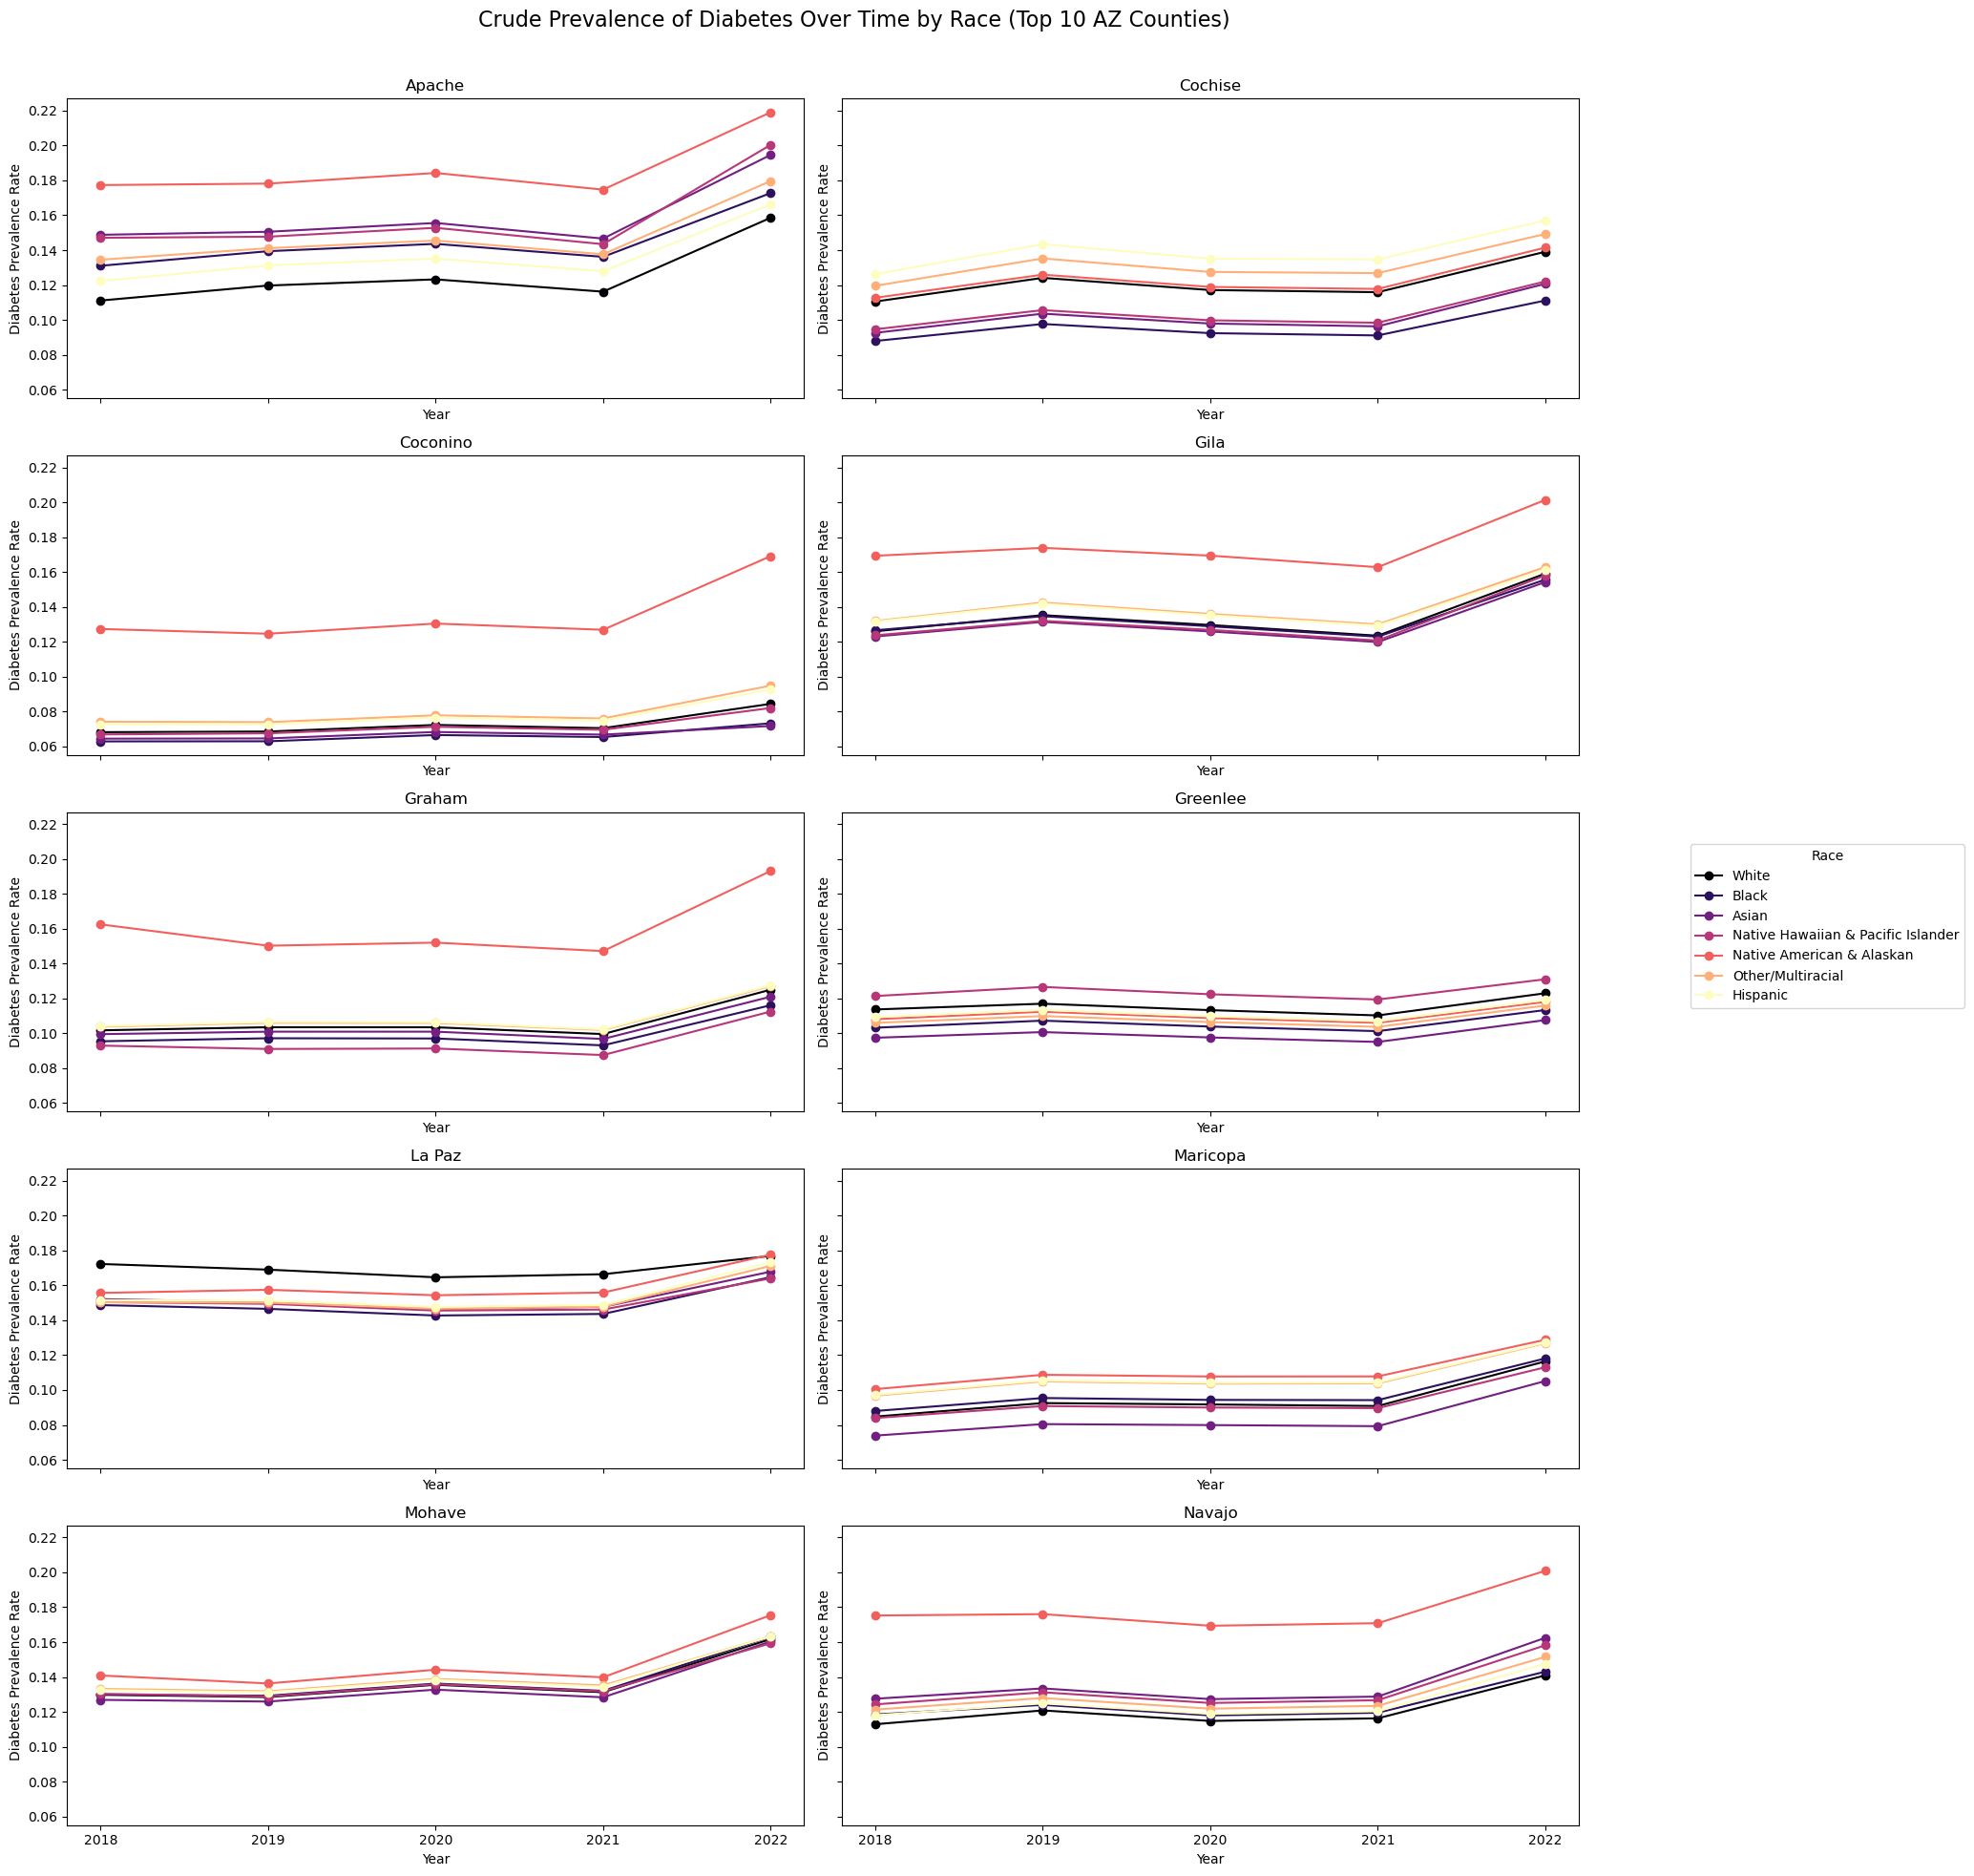

In [93]:
import matplotlib.cm as cm

# Diabetes first
# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define races
race_columns = {
    '%WhiteDiabetes': 'White',
    '%BlackDiabetes': 'Black',
    '%AsianDiabetes': 'Asian',
    '%NHOPIDiabetes': 'Native Hawaiian & Pacific Islander',
    '%AIANDiabetes': 'Native American & Alaskan',
    '%OMultirDiabetes': 'Other/Multiracial',
    '%HispanicDiabetes': 'Hispanic'
}

# Some fun color stuff 
cmap = plt.colormaps.get_cmap('magma').resampled(len(race_columns))
colors = [cmap(i) for i in range(len(race_columns))]

# Create subplot grid
fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True, sharey=True)
axes = axes.flatten()

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].values

    for (col, label), color in zip(race_columns.items(), colors):
        ax.plot(years, subset[col].values, label=label, color=color, marker='o')

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Diabetes Prevalence Rate')

# Create single legend on the side
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Race', loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Diabetes Over Time by Race (Top 10 AZ Counties)', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.93, 0.97])  # adjusts space 
plt.show()

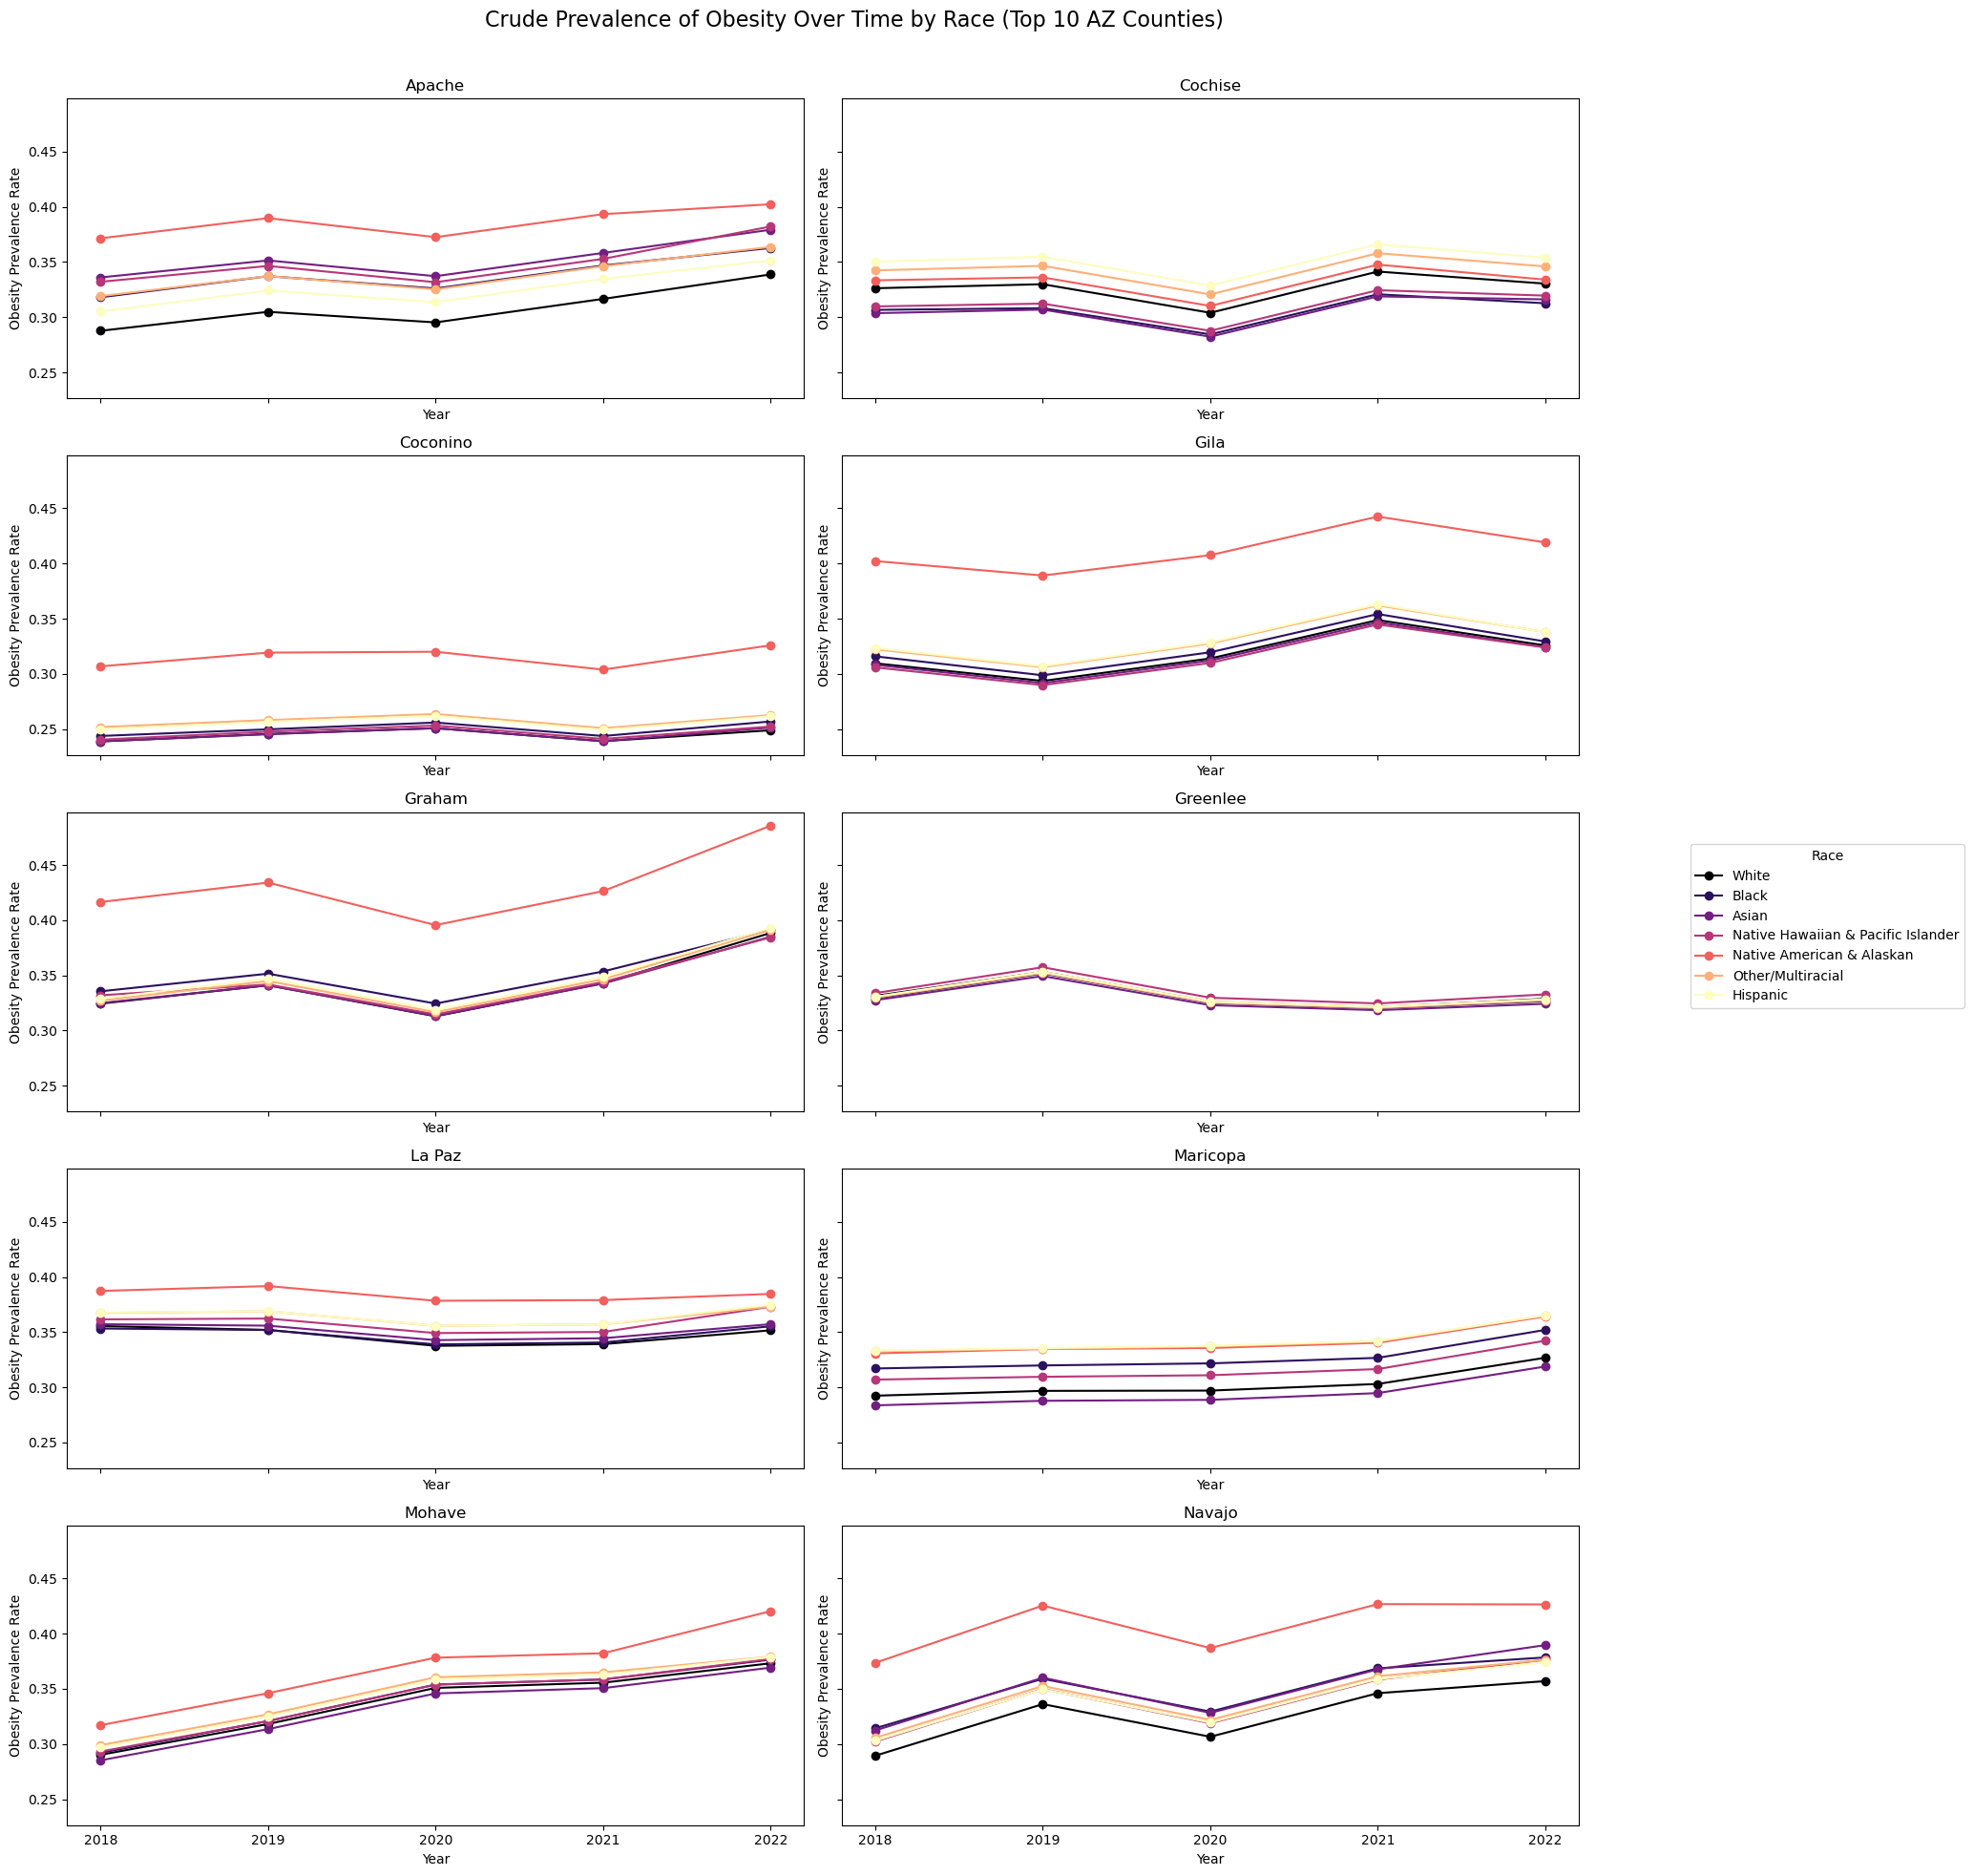

In [94]:
# Obesity Plots Next 

# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define races
race_columns = {
    '%WhiteObesity': 'White',
    '%BlackObesity': 'Black',
    '%AsianObesity': 'Asian',
    '%NHOPIObesity': 'Native Hawaiian & Pacific Islander',
    '%AIANObesity': 'Native American & Alaskan',
    '%OMultirObesity': 'Other/Multiracial',
    '%HispanicObesity': 'Hispanic'
}

# Some fun color stuff 
cmap = plt.colormaps.get_cmap('magma').resampled(len(race_columns))
colors = [cmap(i) for i in range(len(race_columns))]

# Create subplot grid
fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True, sharey=True)
axes = axes.flatten()

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].values

    for (col, label), color in zip(race_columns.items(), colors):
        ax.plot(years, subset[col].values, label=label, color=color, marker='o')

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Obesity Prevalence Rate')

# Create single legend on the side
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, title='Race', loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Obesity Over Time by Race (Top 10 AZ Counties)', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.93, 0.97])  # adjusts space 
plt.show()

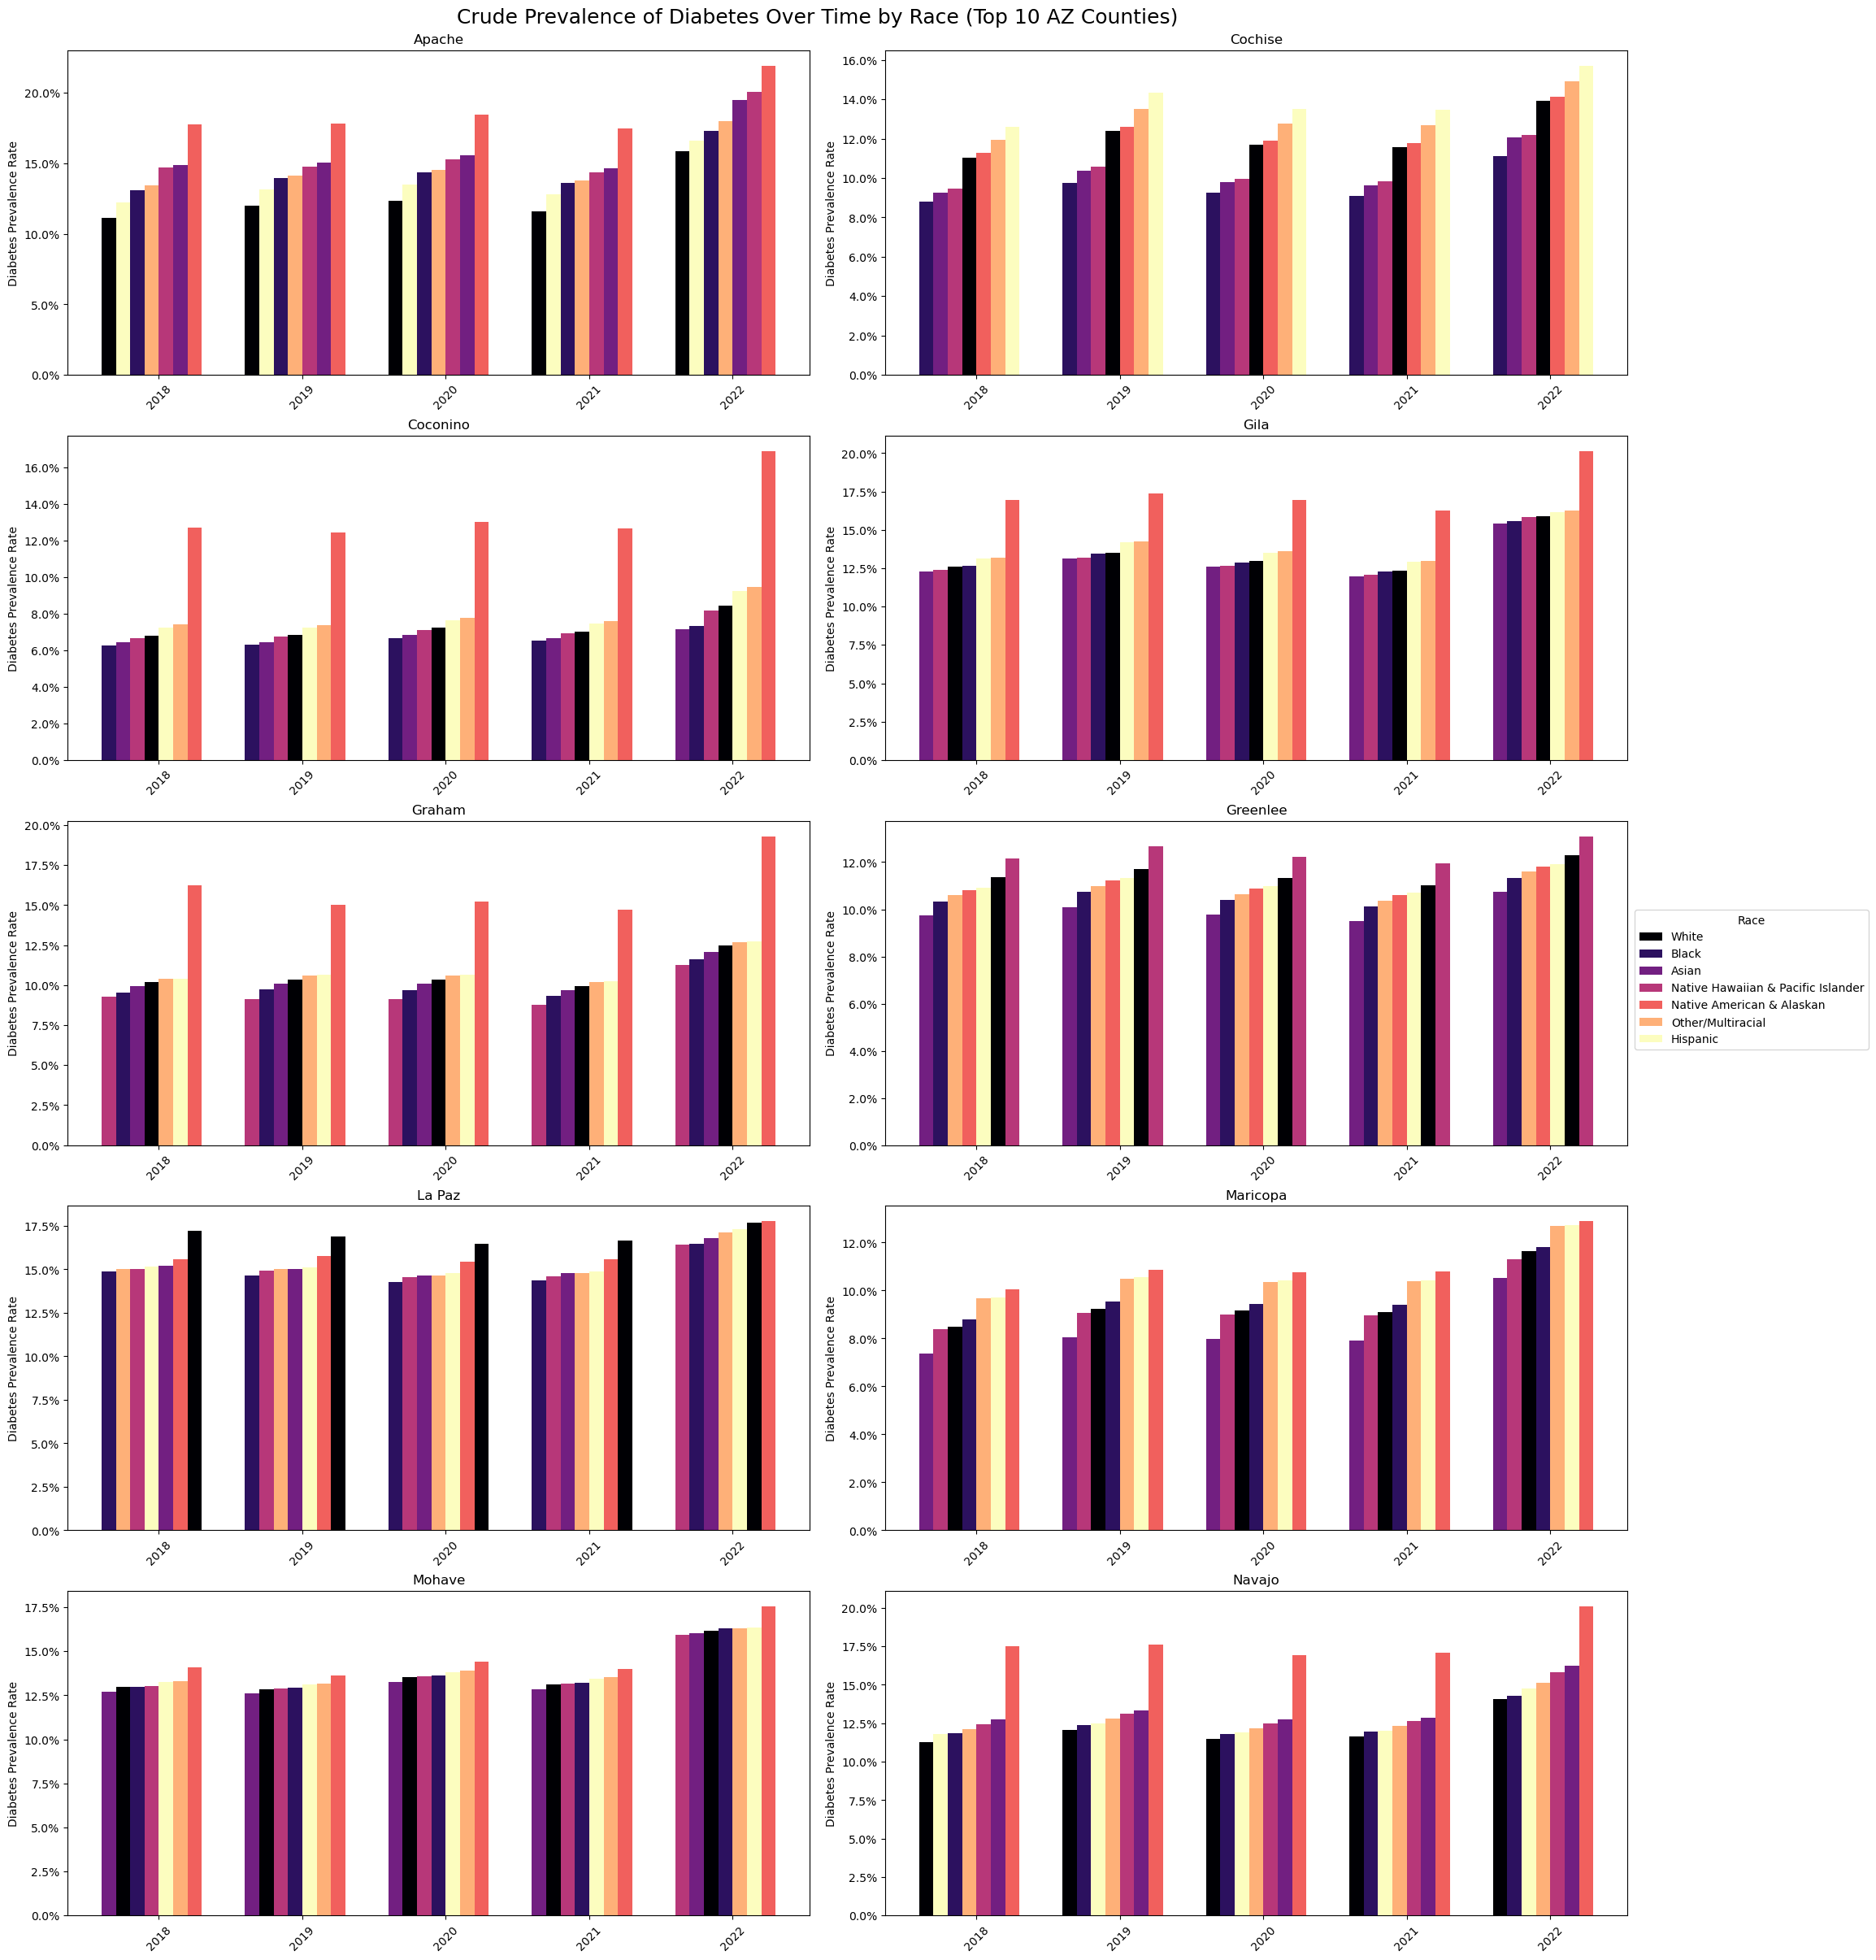

In [186]:
# Test bar plot instead?
from matplotlib.ticker import PercentFormatter

# Diabetes
# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define race columns
race_columns_d = {
    '%WhiteDiabetes': 'White',
    '%BlackDiabetes': 'Black',
    '%AsianDiabetes': 'Asian',
    '%NHOPIDiabetes': 'Native Hawaiian & Pacific Islander',
    '%AIANDiabetes': 'Native American & Alaskan',
    '%OMultirDiabetes': 'Other/Multiracial',
    '%HispanicDiabetes': 'Hispanic'
}

# Colors
cmap = plt.colormaps.get_cmap('magma').resampled(len(race_columns_d))
colors = [cmap(i) for i in range(len(race_columns_d))]
color_map = dict(zip(race_columns_d.values(), colors))  

# Subplot grid
fig, axes = plt.subplots(5, 2, figsize=(20, 24), constrained_layout=True)
axes = axes.flatten()
bar_width = 0.1

for ax in axes.ravel():
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].unique()

    for j, year in enumerate(years):
        row = subset[subset['year'] == year]
        if row.empty:
            continue

        # Collect race data & set up ordering
        race_data = []
        for col, label in race_columns_d.items():
            value = row[col].values[0]
            race_data.append((label, value, color_map[label]))

        # Sort race data 
        sorted_race_data = sorted(race_data, key=lambda x: x[1])

        # Base x-position for years
        base_x = j

        for k, (label, value, color) in enumerate(sorted_race_data):
            offset = base_x + (k - len(race_columns_d)/2) * bar_width
            ax.bar(offset, value, width=bar_width, color=color)

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xticks(np.arange(len(years)))
    ax.set_xticklabels(years, rotation=45)
    ax.set_ylabel('Diabetes Prevalence Rate')

# One legend for all plots, manually made bc of the new ascedning order of the bars 
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label)
                   for i, label in enumerate(race_columns_d.values())]

fig.legend(handles=legend_elements, title='Race',
           loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Diabetes Over Time by Race (Top 10 AZ Counties)', fontsize=18)
plt.show()


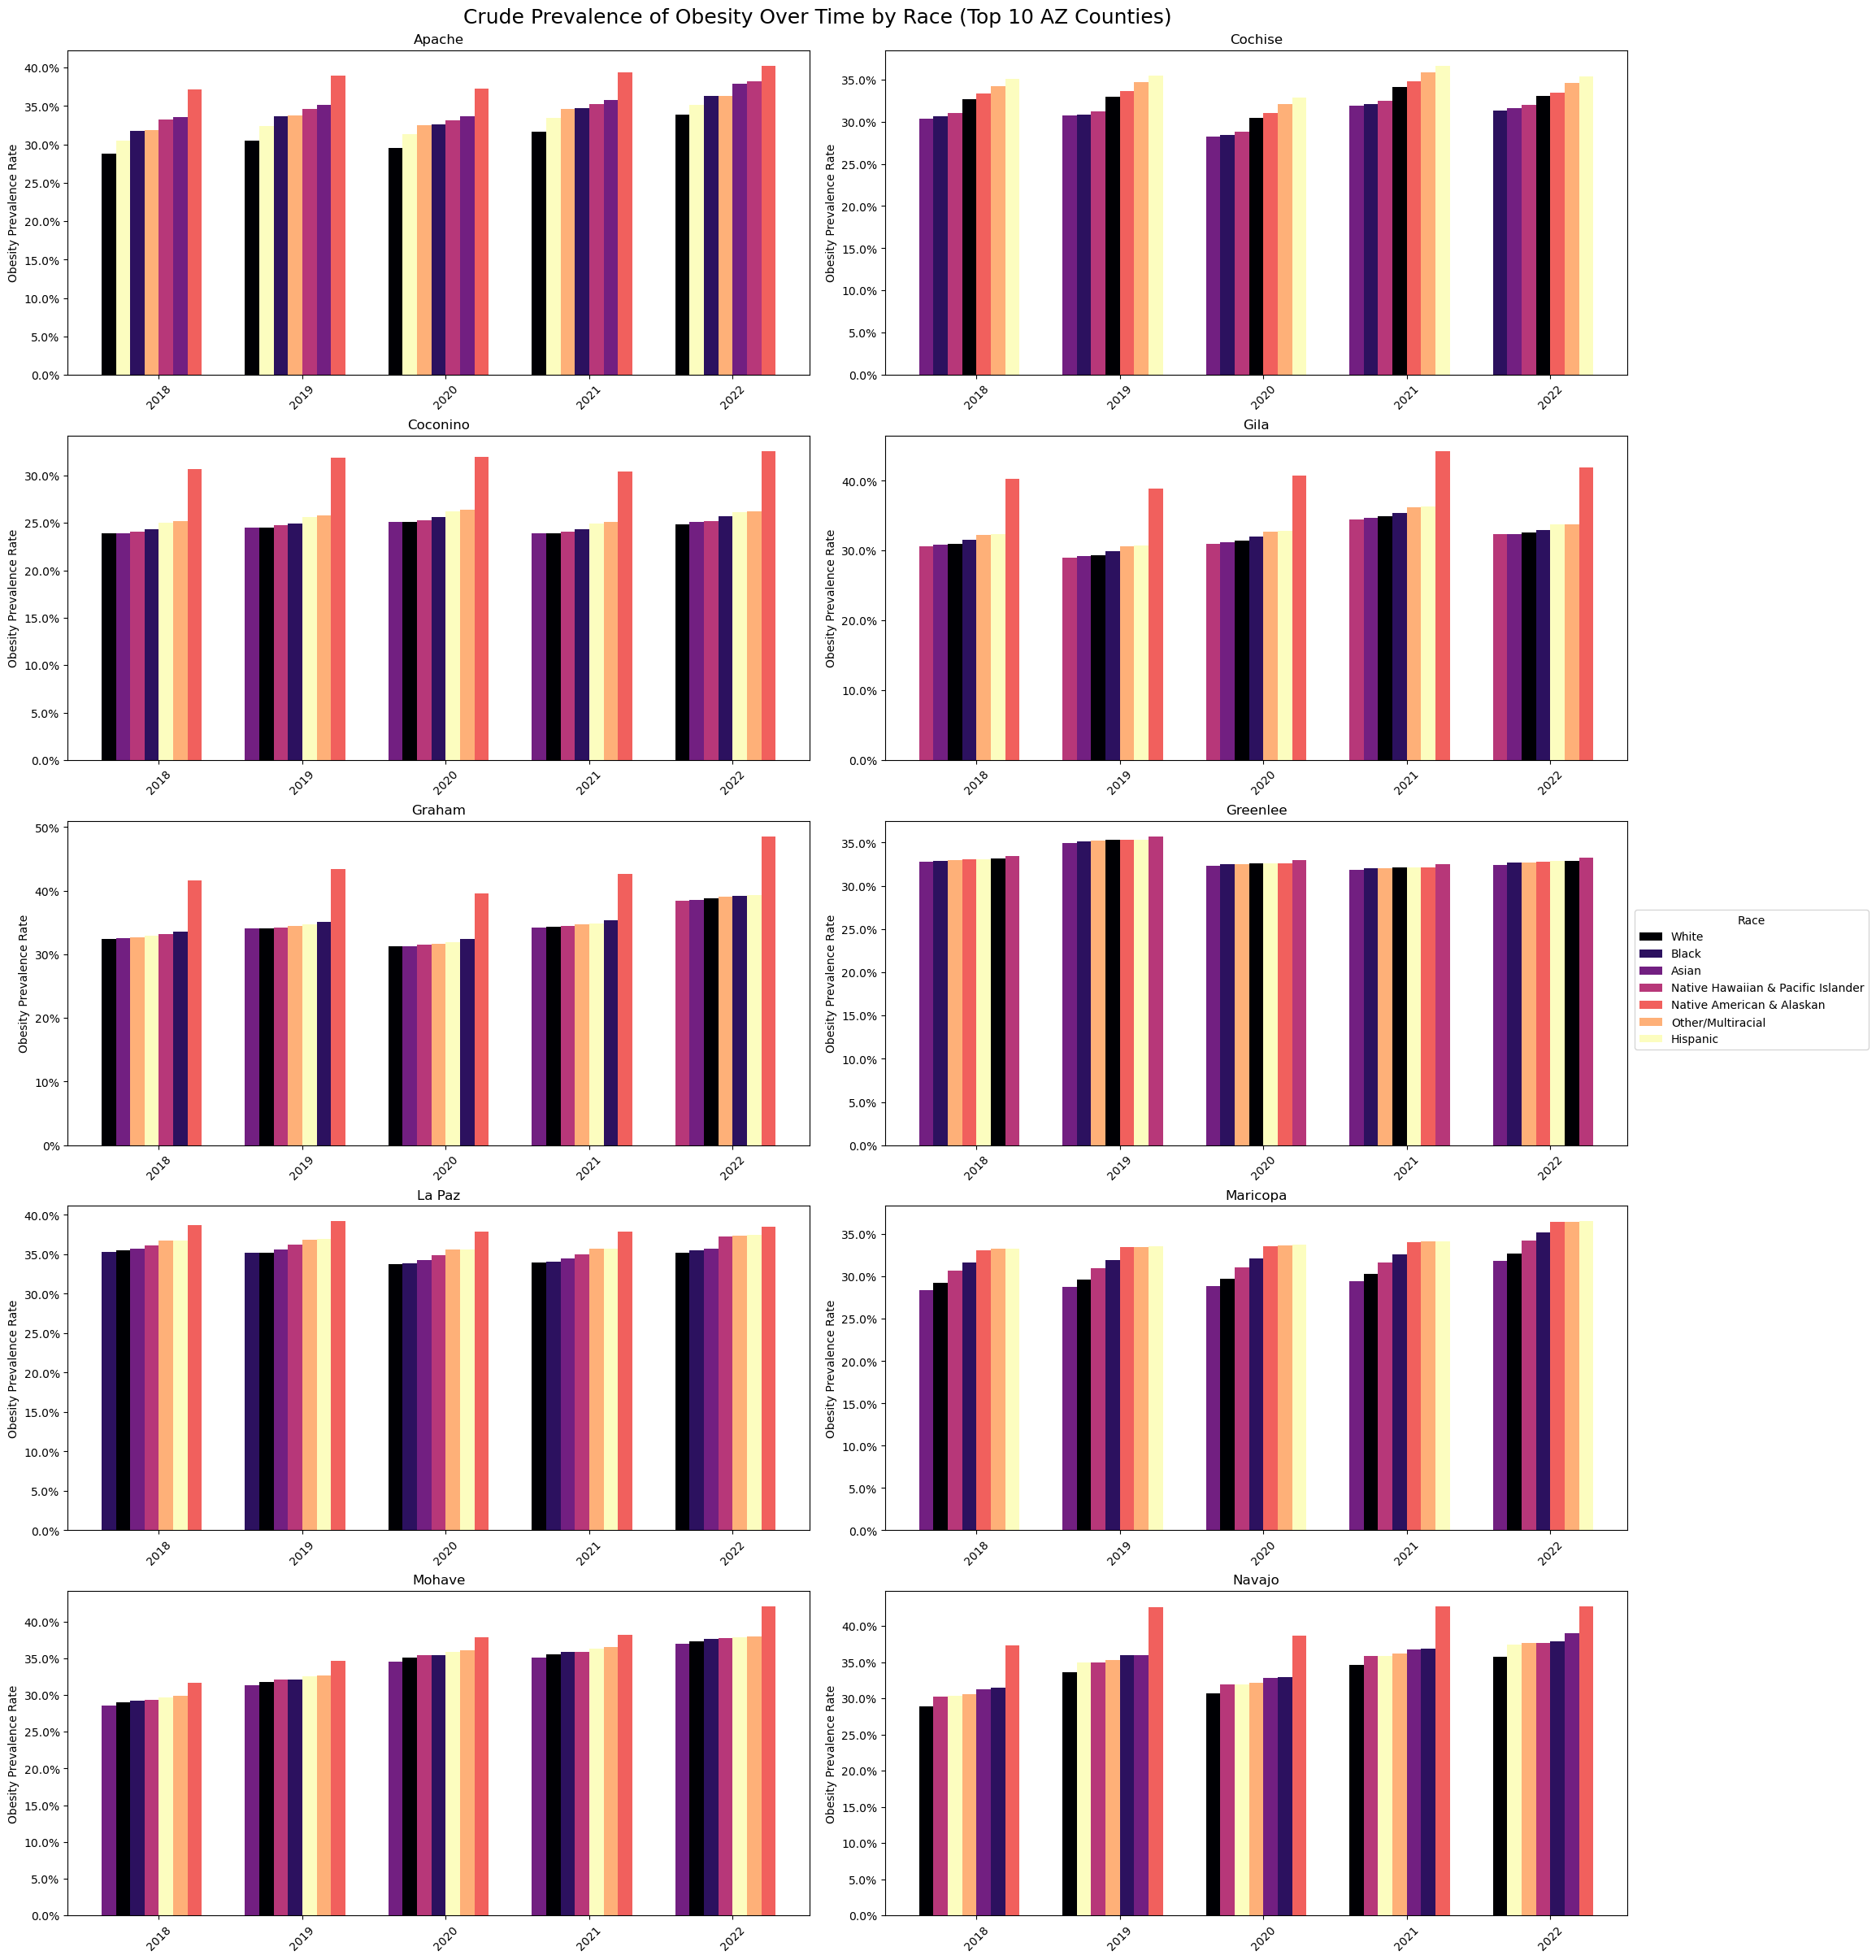

In [187]:
# Bar for Obesity 

# Define top 10 counties
counties = [
    'Apache', 'Cochise', 'Coconino', 'Gila', 'Graham',
    'Greenlee', 'La Paz', 'Maricopa', 'Mohave', 'Navajo'
]

# Define race columns for obesity
race_columns_o = {
    '%WhiteObesity': 'White',
    '%BlackObesity': 'Black',
    '%AsianObesity': 'Asian',
    '%NHOPIObesity': 'Native Hawaiian & Pacific Islander',
    '%AIANObesity': 'Native American & Alaskan',
    '%OMultirObesity': 'Other/Multiracial',
    '%HispanicObesity': 'Hispanic'
}

# Colors
cmap = plt.colormaps.get_cmap('magma').resampled(len(race_columns_o))
colors = [cmap(i) for i in range(len(race_columns_o))]
color_map = dict(zip(race_columns_o.values(), colors))  

# Subplot grid
fig, axes = plt.subplots(5, 2, figsize=(20, 24), constrained_layout=True)
axes = axes.flatten()
bar_width = 0.1

for ax in axes.ravel():
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))

for idx, county in enumerate(counties):
    ax = axes[idx]
    subset = Unioned_Data_By_Race[Unioned_Data_By_Race['CountyName'] == county]
    years = subset['year'].unique()

    for j, year in enumerate(years):
        row = subset[subset['year'] == year]
        if row.empty:
            continue

        # Collect race data & set up ordering
        race_data = []
        for col, label in race_columns_o.items():
            value = row[col].values[0]
            race_data.append((label, value, color_map[label]))

        # Sort race data 
        sorted_race_data = sorted(race_data, key=lambda x: x[1])

        # Base x-position for years
        base_x = j

        for k, (label, value, color) in enumerate(sorted_race_data):
            offset = base_x + (k - len(race_columns_o)/2) * bar_width
            ax.bar(offset, value, width=bar_width, color=color)

    ax.set_title(f'{county}', fontsize=12)
    ax.set_xticks(np.arange(len(years)))
    ax.set_xticklabels(years, rotation=45)
    ax.set_ylabel('Obesity Prevalence Rate')

# One legend for all plots, manually made bc of the new ascedning order of the bars 
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label)
                   for i, label in enumerate(race_columns_o.values())]

fig.legend(handles=legend_elements, title='Race',
           loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.suptitle('Crude Prevalence of Obesity Over Time by Race (Top 10 AZ Counties)', fontsize=18)
plt.show()

In [189]:
# Some basic regression work -- AINA (Native American $ Alaskan Native Race) serves as baseline
import statsmodels.formula.api as smf

# Melt into long format
df_long = pd.melt(
    Unioned_Data_By_Race,
    id_vars=["CountyName", "year"],
    var_name="Race_Outcome",
    value_name="Percentage"
)

# Split race and outcomes 
df_long["Race"] = df_long["Race_Outcome"].str.extract(r'%(\w+?)(?:Obesity|Diabetes)')
df_long["Outcome"] = df_long["Race_Outcome"].str.extract(r'(Obesity|Diabetes)')

df_long.drop(columns="Race_Outcome", inplace=True)


In [190]:
# Start with obesity 
obesity_df = df_long[df_long["Outcome"] == "Obesity"].dropna()

# Run model with race and year
model = smf.ols("Percentage ~ C(Race) + C(year)", data=obesity_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Percentage   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     10.40
Date:                Tue, 12 Aug 2025   Prob (F-statistic):           4.51e-16
Time:                        11:24:56   Log-Likelihood:                 966.66
No. Observations:                 525   AIC:                            -1911.
Df Residuals:                     514   BIC:                            -1864.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.3600    

In [191]:
# Diabetes now
diabetes_df = df_long[df_long["Outcome"] == "Diabetes"].dropna()

# Run model with race and year
model = smf.ols("Percentage ~ C(Race) + C(year)", data=diabetes_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Percentage   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.266
Method:                 Least Squares   F-statistic:                     20.03
Date:                Tue, 12 Aug 2025   Prob (F-statistic):           2.30e-31
Time:                        11:24:59   Log-Likelihood:                 1210.7
No. Observations:                 525   AIC:                            -2399.
Df Residuals:                     514   BIC:                            -2353.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.1399    

In [192]:
# Want to look at race alone with regressions and % diseases 

# Obesity 
model = smf.ols("Percentage ~ C(Race)", data=obesity_df).fit()
print(model.summary())

# Diabetes 
model = smf.ols("Percentage ~ C(Race)", data=diabetes_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Percentage   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     11.50
Date:                Tue, 12 Aug 2025   Prob (F-statistic):           4.26e-12
Time:                        11:25:01   Log-Likelihood:                 951.14
No. Observations:                 525   AIC:                            -1888.
Df Residuals:                     518   BIC:                            -1858.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.3697    

In [193]:
# Dive deeper with quantile regressions -- AINA (Native American $ Alaskan Native Race) serves as baseline

# Obesity 
for q in [0.25, 0.5, 0.75]: # cover bases by hitting lower, median, higher 
    print(f"\nQuantile Regression at q = {q}")
    
    model = smf.quantreg("Percentage ~ C(Race)", data=obesity_df)
    result = model.fit(q=q)
    
    print(result.summary())


Quantile Regression at q = 0.25
                         QuantReg Regression Results                          
Dep. Variable:             Percentage   Pseudo R-squared:              0.04365
Model:                       QuantReg   Bandwidth:                     0.02189
Method:                 Least Squares   Sparsity:                       0.1293
Date:                Tue, 12 Aug 2025   No. Observations:                  525
Time:                        11:25:04   Df Residuals:                      518
                                        Df Model:                            6
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.3334      0.006     51.321      0.000       0.321       0.346
C(Race)[T.Asian]       -0.0417      0.009     -4.544      0.000      -0.060      -0.024
C(Race)[T.Black]       -0.0208      0.009     -2.261      0.02

In [194]:
# Diabetes 
for q in [0.25, 0.5, 0.75]: # cover bases by hitting lower, median, higher 
    print(f"\nQuantile Regression at q = {q}")
    
    model = smf.quantreg("Percentage ~ C(Race)", data=diabetes_df)
    result = model.fit(q=q)
    
    print(result.summary())


Quantile Regression at q = 0.25
                         QuantReg Regression Results                          
Dep. Variable:             Percentage   Pseudo R-squared:              0.06969
Model:                       QuantReg   Bandwidth:                     0.01514
Method:                 Least Squares   Sparsity:                      0.07019
Date:                Tue, 12 Aug 2025   No. Observations:                  525
Time:                        11:25:06   Df Residuals:                      518
                                        Df Model:                            6
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.1269      0.004     35.985      0.000       0.120       0.134
C(Race)[T.Asian]       -0.0305      0.005     -6.126      0.000      -0.040      -0.021
C(Race)[T.Black]       -0.0305      0.005     -6.113      0.00

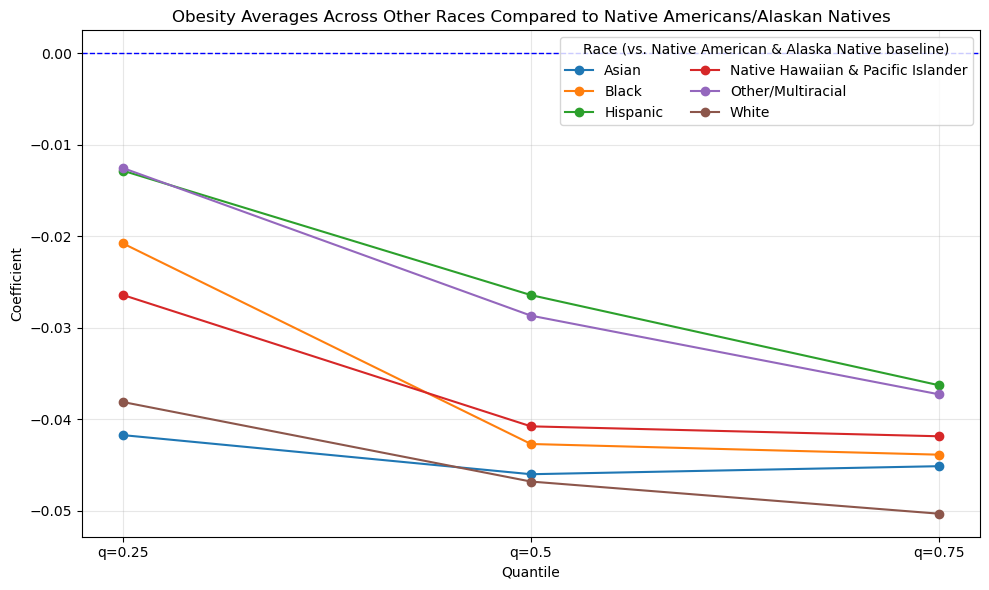

In [ ]:
# Make visuals with qreg results - Obesity 
import re 
# Set up quantiles to plot 
quantiles = [0.25, 0.5, 0.75]
coef_df_list = []

# Run quantile regressions
for q in quantiles:
    model = smf.quantreg("Percentage ~ C(Race, Treatment(reference='AIAN'))", data=obesity_df)
    result = model.fit(q=q)
    coefs = result.params
    coefs.name = f"q={q}"
    coef_df_list.append(coefs)

# Combine long
coef_plot_df = pd.concat(coef_df_list, axis=1).T.reset_index()
coef_plot_df = coef_plot_df.rename(columns={"index": "Quantile"})

# Plot set up 
fig, ax = plt.subplots(figsize=(10, 6))

# helper to convert stats terms for pretty labeling 
code_map = {
    'Asian': 'Asian',
    'Black': 'Black',
    'Hispanic': 'Hispanic',
    'NHOPI': 'Native Hawaiian & Pacific Islander',
    'OMultir': 'Other/Multiracial',
    'White': 'White'
}
def pretty_label(term: str) -> str:
    m = re.search(r'\[T\.(.+?)\]', term)  # captures everything between [T. and ] for labeling 
    return code_map.get(m.group(1), m.group(1) if m else term)

# draw lines w labels, loop thru race coefs 
for col in coef_plot_df.columns:
    if col not in ("Quantile", "Intercept"):
        label = pretty_label(col)
        ax.plot(coef_plot_df["Quantile"], coef_plot_df[col], marker="o", label=label)

# zero ref line
ax.axhline(0, color='blue', linestyle='--', linewidth=1)

# Build and order llegend 
order = ['Asian','Black','Hispanic','Native Hawaiian & Pacific Islander','Other/Multiracial','White']
handles, labels = ax.get_legend_handles_labels()
bylabel = {lab: h for h, lab in zip(handles, labels)}         
ordered_labels = [l for l in order if l in bylabel]
ordered_handles = [bylabel[l] for l in ordered_labels]
ax.legend(ordered_handles, ordered_labels,
          title='Race (vs. Native American & Alaska Native baseline)',
          loc='upper right', frameon=True, ncol=2)

ax.set_title("Obesity Averages Across Other Races Compared to Native Americans/Alaskan Natives")
ax.set_xlabel("Quantile")
ax.set_ylabel("Coefficient")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

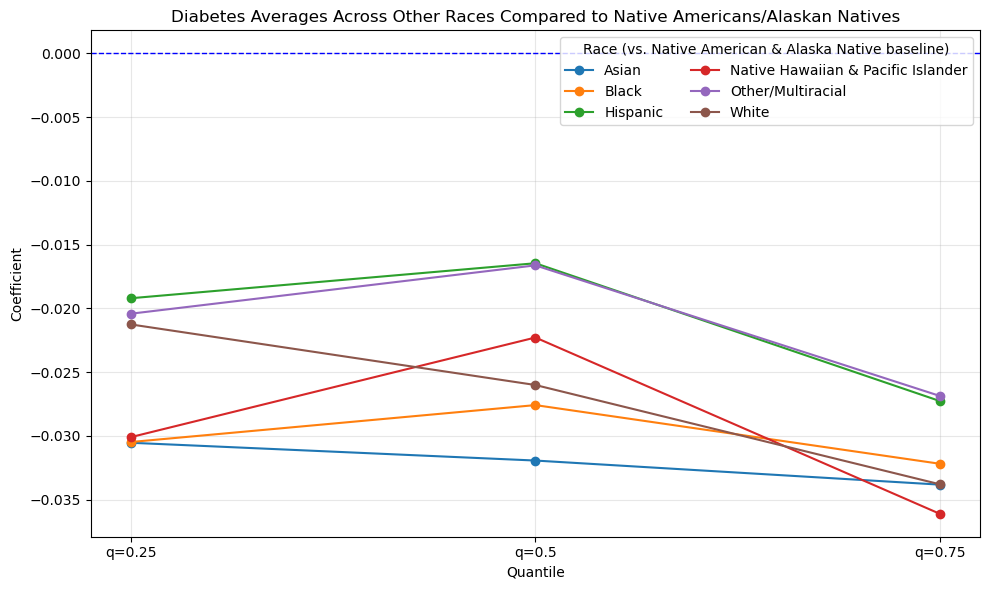

In [197]:
# Make visuals with qreg results - Diabetes 
# Set up quantiles to plot 
quantiles = [0.25, 0.5, 0.75]
coef_df_list = []

# Run quantile regressions
for q in quantiles:
    model = smf.quantreg("Percentage ~ C(Race, Treatment(reference='AIAN'))", data=diabetes_df)
    result = model.fit(q=q)
    coefs = result.params
    coefs.name = f"q={q}"
    coef_df_list.append(coefs)

# Combine long
coef_plot_df = pd.concat(coef_df_list, axis=1).T.reset_index()
coef_plot_df = coef_plot_df.rename(columns={"index": "Quantile"})

# Plot set up 
fig, ax = plt.subplots(figsize=(10, 6))

# helper to convert stats terms for pretty labeling 
code_map = {
    'Asian': 'Asian',
    'Black': 'Black',
    'Hispanic': 'Hispanic',
    'NHOPI': 'Native Hawaiian & Pacific Islander',
    'OMultir': 'Other/Multiracial',
    'White': 'White'
}
def pretty_label(term: str) -> str:
    m = re.search(r'\[T\.(.+?)\]', term)  # captures everything between [T. and ] for labeling 
    return code_map.get(m.group(1), m.group(1) if m else term)

# draw lines w labels, loop thru race coefs 
for col in coef_plot_df.columns:
    if col not in ("Quantile", "Intercept"):
        label = pretty_label(col)
        ax.plot(coef_plot_df["Quantile"], coef_plot_df[col], marker="o", label=label)

# zero ref line
ax.axhline(0, color='blue', linestyle='--', linewidth=1)

# Build and order llegend 
order = ['Asian','Black','Hispanic','Native Hawaiian & Pacific Islander','Other/Multiracial','White']
handles, labels = ax.get_legend_handles_labels()
bylabel = {lab: h for h, lab in zip(handles, labels)}         
ordered_labels = [l for l in order if l in bylabel]
ordered_handles = [bylabel[l] for l in ordered_labels]
ax.legend(ordered_handles, ordered_labels,
          title='Race (vs. Native American & Alaska Native baseline)',
          loc='upper right', frameon=True, ncol=2)

ax.set_title("Diabetes Averages Across Other Races Compared to Native Americans/Alaskan Natives")
ax.set_xlabel("Quantile")
ax.set_ylabel("Coefficient")
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
# Multiple Linear Regression, goal is %rate ~ c(race) * obesity or diabetes 

# Create a long df 
df_long = pd.melt(
    Unioned_Data_By_Race,
    id_vars=["CountyName", "year"],
    var_name="Race_Outcome",
    value_name="Percentage"
)

# Extract race & outcomes
df_long["Race"] = df_long["Race_Outcome"].str.extract(r'%(\w+?)(?:Obesity|Diabetes)')
df_long["Outcome"] = df_long["Race_Outcome"].str.extract(r'(Obesity|Diabetes)')

# Separate disease rows 
obesity_df = df_long[df_long["Outcome"] == "Obesity"].dropna().rename(columns={"Percentage": "ObesityRate"})
diabetes_df = df_long[df_long["Outcome"] == "Diabetes"].dropna().rename(columns={"Percentage": "DiabetesRate"})

# Merge disease rows 
df_wide = pd.merge(
    obesity_df[["CountyName", "year", "Race", "ObesityRate"]],
    diabetes_df[["CountyName", "year", "Race", "DiabetesRate"]],
    on=["CountyName", "year", "Race"]
)

# AINA is our baseline 
df_wide["Race"] = pd.Categorical(df_wide["Race"])
df_wide["Race"] = df_wide["Race"].cat.reorder_categories(
    sorted(df_wide["Race"].dropna().unique(), key=lambda x: 0 if "AIAN" in x else 1)
)

# Model 1-- Predicting obesity based on race * diabetes
model1 = smf.ols("ObesityRate ~ C(Race) * DiabetesRate", data=df_wide).fit()
print("\n=== Obesity Rate ~ C(Race) * Diabetes ===")
print(model1.summary())

# Model 2-- Predicting diabetes based on race * obesity
model2 = smf.ols("DiabetesRate ~ C(Race) * ObesityRate", data=df_wide).fit()
print("\n=== Diabetes Rate ~ C(Race) * Obesity ===")
print(model2.summary())



=== Obesity Rate ~ C(Race) * Diabetes ===
                            OLS Regression Results                            
Dep. Variable:            ObesityRate   R-squared:                       0.427
Model:                            OLS   Adj. R-squared:                  0.412
Method:                 Least Squares   F-statistic:                     29.26
Date:                Tue, 05 Aug 2025   Prob (F-statistic):           1.11e-53
Time:                        19:21:13   Log-Likelihood:                 1064.4
No. Observations:                 525   AIC:                            -2101.
Df Residuals:                     511   BIC:                            -2041.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [ ]:
# Polynomial Regression -- looking at obesity/diabetes and income levels
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# First prepare the data i need from FARA 
AZ_FARA = FARA[FARA['State'] == 'Arizona']

# Clean county name to match Unioned_Data_By_Race
AZ_FARA['CountyName'] = AZ_FARA['County'].str.replace(' County', '', regex=False).str.strip()

# Merge MedianFamilyIncome into the unioned data by race df 
income_merged_df = Unioned_Data_By_Race.merge(
    AZ_FARA[['CountyName', 'MedianFamilyIncome']],
    on='CountyName',
    how='left'
)

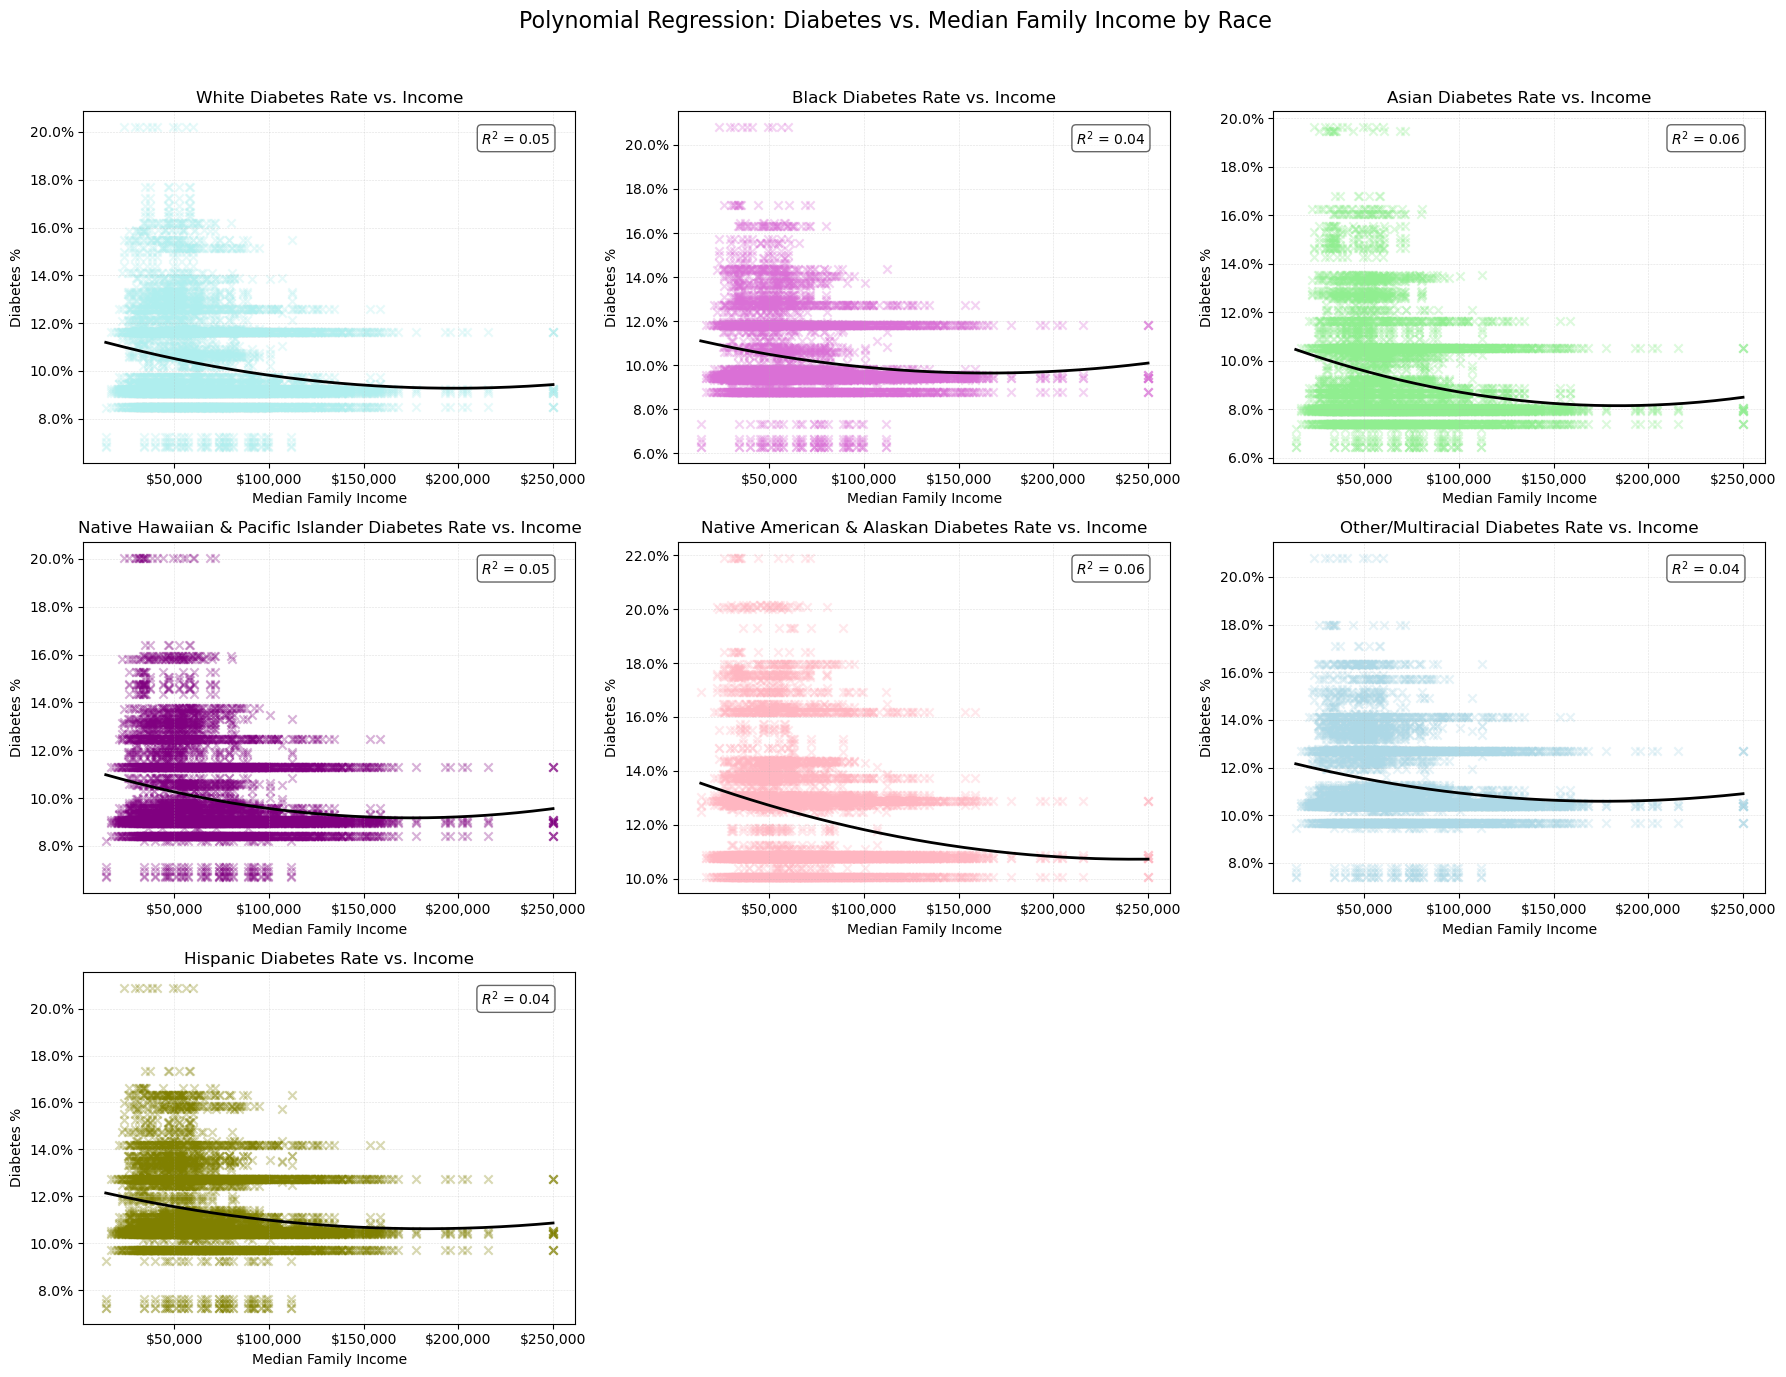

In [ ]:
# Plot polynomial reg by race with diabetes 
from matplotlib import ticker

# Define cols
diabetes_columns = {
    '%WhiteDiabetes': 'White',
    '%BlackDiabetes': 'Black',
    '%AsianDiabetes': 'Asian',
    '%NHOPIDiabetes': 'Native Hawaiian & Pacific Islander',
    '%AIANDiabetes': 'Native American & Alaskan',
    '%OMultirDiabetes': 'Other/Multiracial',
    '%HispanicDiabetes': 'Hispanic'
}

colors = ['paleturquoise', 'orchid', 'lightgreen', 'purple', 'lightpink', 'lightblue', 'olive']

# Set up subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# Loop through races and make plots
for idx, (col, label) in enumerate(diabetes_columns.items()):
    ax = axes[idx]

    # Drop null values for current race
    temp = income_merged_df[[col, 'MedianFamilyIncome']].dropna()
    X = temp[['MedianFamilyIncome']].values
    y = temp[col].values

    # Fit polynomial regression 
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)

    # Predict for smoothed curve
    X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_pred = model.predict(X_range_poly)

    # R2 score
    r2 = r2_score(y, model.predict(X_poly))

    # Plot
    ax.scatter(X, y, alpha=0.3, color=colors[idx], marker='x', label='Data')
    ax.plot(X_range, y_pred, color='black', linewidth=2)

    ax.set_title(f"{label} Diabetes Rate vs. Income", fontsize=12)
    ax.set_xlabel("Median Family Income")
    ax.set_ylabel("Diabetes %")
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

    # Format x-axis as $ and y-axis as %
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

    # Add R2 score 
    ax.text(0.95, 0.95, f"$R^2$ = {r2:.2f}",
            transform=ax.transAxes,
            fontsize=10, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

# Hide unused subplots
for j in range(len(diabetes_columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Polynomial Regression: Diabetes vs. Median Family Income by Race", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

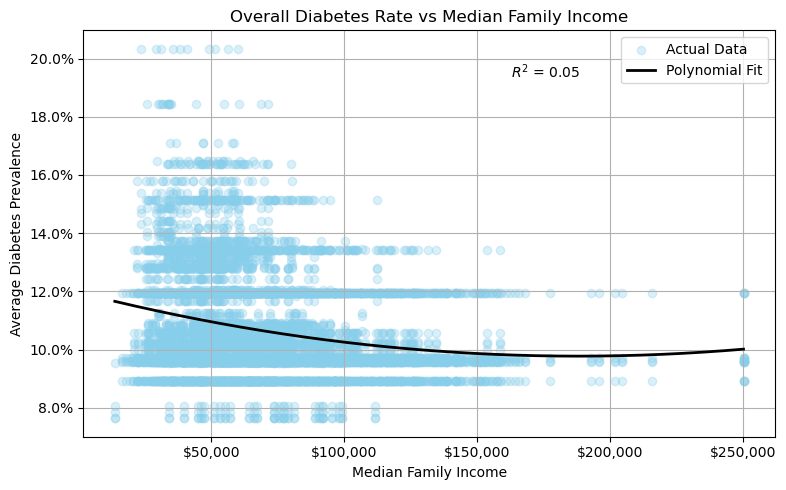

In [ ]:
# Average diabetes prevalence across all races
income_merged_df["AvgDiabetesRate"] = income_merged_df[list(diabetes_columns.keys())].mean(axis=1)

# Drop null values
df_all = income_merged_df[["MedianFamilyIncome", "AvgDiabetesRate"]].dropna()

X_all = df_all[["MedianFamilyIncome"]].values
y_all = df_all["AvgDiabetesRate"].values

# Polynomial transformation
poly = PolynomialFeatures(degree=2)
X_poly_all = poly.fit_transform(X_all)

# Fit model
model_all = LinearRegression()
model_all.fit(X_poly_all, y_all)

# Smooth prediction line
X_plot = np.linspace(X_all.min(), X_all.max(), 300).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model_all.predict(X_plot_poly)

r2_all = r2_score(y_all, model_all.predict(X_poly_all))

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_all, y_all, color="skyblue", alpha=0.3, label="Actual Data")
plt.plot(X_plot, y_plot, color="black", linewidth=2, label="Polynomial Fit")
plt.title("Overall Diabetes Rate vs Median Family Income")
plt.xlabel("Median Family Income")
plt.ylabel("Average Diabetes Prevalence")

# Format ticks
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

# R2 on plot 
plt.text(
    X_all.max() * 0.65,
    y_all.max() * 0.95,
    f"$R^2$ = {r2_all:.2f}",
    fontsize=10,
    color="black"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

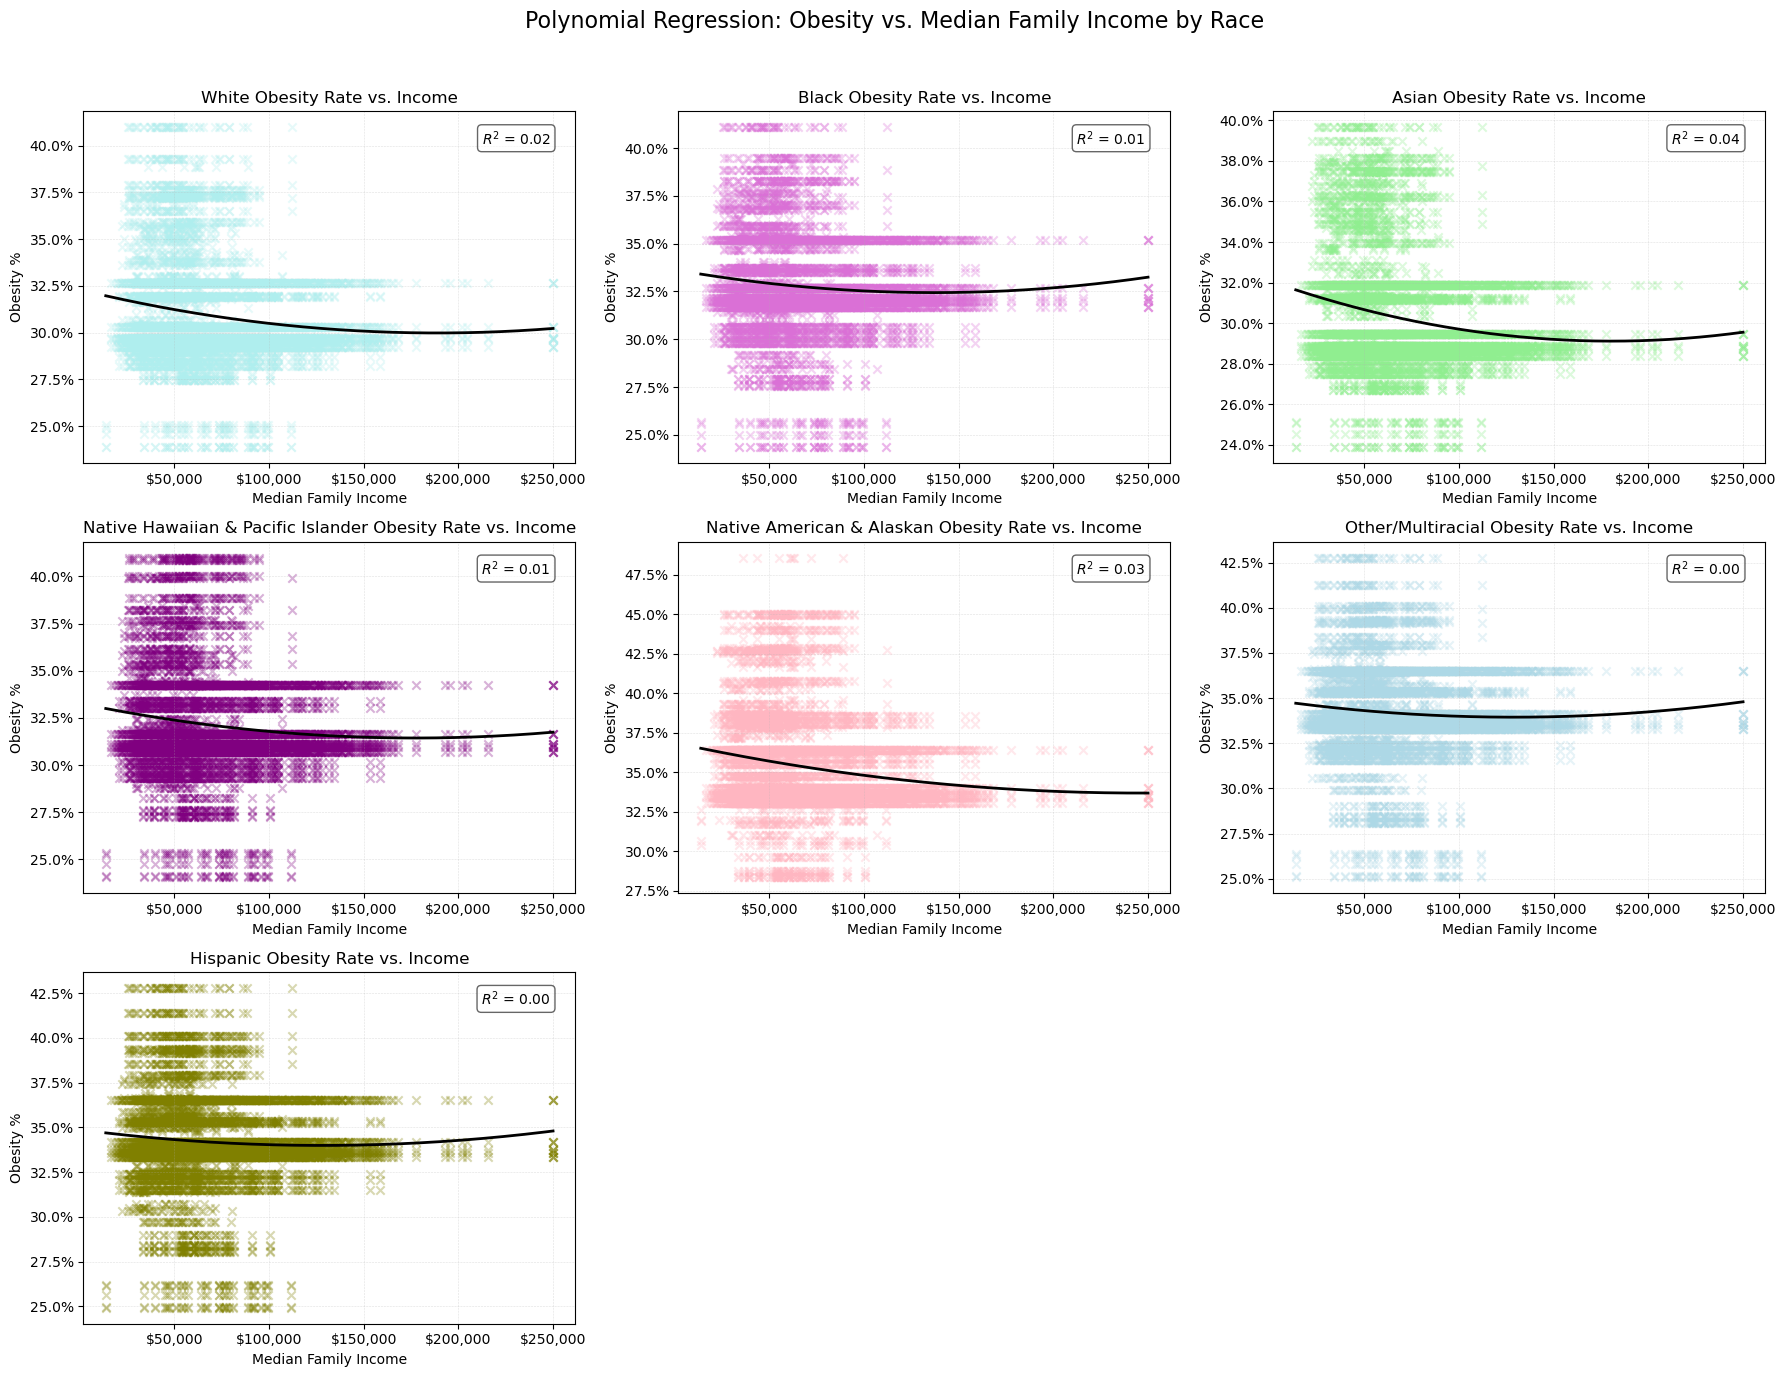

In [ ]:
# Plot polynomial reg by race with obesity

# Define obesity columns by race
obesity_columns = {
    '%WhiteObesity': 'White',
    '%BlackObesity': 'Black',
    '%AsianObesity': 'Asian',
    '%NHOPIObesity': 'Native Hawaiian & Pacific Islander',
    '%AIANObesity': 'Native American & Alaskan',
    '%OMultirObesity': 'Other/Multiracial',
    '%HispanicObesity': 'Hispanic'
}

colors = ['paleturquoise', 'orchid', 'lightgreen', 'purple', 'lightpink', 'lightblue', 'olive']

# Set up subplot grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

# Loop through races and make plots
for idx, (col, label) in enumerate(obesity_columns.items()):
    ax = axes[idx]

    # Drop null values for current race
    temp = income_merged_df[[col, 'MedianFamilyIncome']].dropna()
    X = temp[['MedianFamilyIncome']].values
    y = temp[col].values

    # Fit polynomial regression 
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    model.fit(X_poly, y)

    # Predict for smoothed curve
    X_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_pred = model.predict(X_range_poly)

    # R2 score
    r2 = r2_score(y, model.predict(X_poly))

    # Plot
    ax.scatter(X, y, alpha=0.3, color=colors[idx], marker='x', label='Data')
    ax.plot(X_range, y_pred, color='black', linewidth=2)

    ax.set_title(f"{label} Obesity Rate vs. Income", fontsize=12)
    ax.set_xlabel("Median Family Income")
    ax.set_ylabel("Obesity %")
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.4)

    # Format x-axis as $ and y-axis as % 
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))

    # Add R2 score 
    ax.text(0.95, 0.95, f"$R^2$ = {r2:.2f}",
            transform=ax.transAxes,
            fontsize=10, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.6))

# Hide unused subplots
for j in range(len(obesity_columns), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Polynomial Regression: Obesity vs. Median Family Income by Race", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

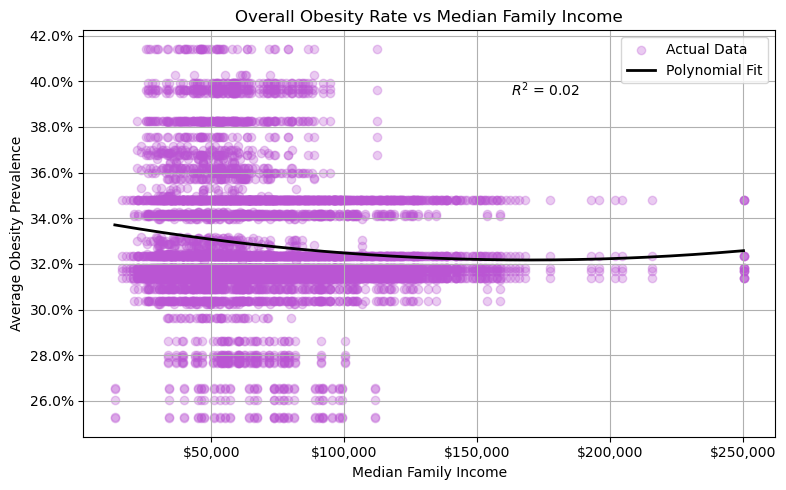

In [ ]:
# Average obesity prevalence across all races
income_merged_df["AvgObesityRate"] = income_merged_df[list(obesity_columns.keys())].mean(axis=1)

# Drop null values
df_all = income_merged_df[["MedianFamilyIncome", "AvgObesityRate"]].dropna()

X_all = df_all[["MedianFamilyIncome"]].values
y_all = df_all["AvgObesityRate"].values

# Polynomial transformation
poly = PolynomialFeatures(degree=2)
X_poly_all = poly.fit_transform(X_all)

# Fit model
model_all = LinearRegression()
model_all.fit(X_poly_all, y_all)

# Smooth prediction line
X_plot = np.linspace(X_all.min(), X_all.max(), 300).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
y_plot = model_all.predict(X_plot_poly)

r2_all = r2_score(y_all, model_all.predict(X_poly_all))

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X_all, y_all, color="mediumorchid", alpha=0.3, label="Actual Data")
plt.plot(X_plot, y_plot, color="black", linewidth=2, label="Polynomial Fit")
plt.title("Overall Obesity Rate vs Median Family Income")
plt.xlabel("Median Family Income")
plt.ylabel("Average Obesity Prevalence")

# Format ticks
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

# R2 on plot 
plt.text(
    X_all.max() * 0.65,
    y_all.max() * 0.95,
    f"$R^2$ = {r2_all:.2f}",
    fontsize=10,
    color="black"
)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Cole's standard error setup 

AGG_Columns_to_extract = ['year','%WhiteDiabetes','%WhiteObesity','%BlackDiabetes','%BlackObesity','%AsianDiabetes','%AsianObesity',
                     '%NHOPIDiabetes','%NHOPIObesity','%AIANDiabetes','%AIANObesity','%OMultirDiabetes','%OMultirObesity',
                     '%HispanicDiabetes','%HispanicObesity']
Unioned_Data_By_Race2 = Unioned_Data_By_Race[AGG_Columns_to_extract]
Unioned_Data_By_Race2
AGG_DATA = Unioned_Data_By_Race2.groupby('year').agg(['mean','std'])
def sem(x):
    return x.std()/np.sqrt(len(x))
AGG_DATA_SEM = Unioned_Data_By_Race2.groupby('year').agg(['mean',sem])
AGG_DATA_SEM = AGG_DATA_SEM.rename(columns = {'sem': 'std_error_mean'})
AGG_DATA_SEM

%WhiteDiabetes                %WhiteObesity                 \
               mean std_error_mean          mean std_error_mean   
year                                                              
2018       0.114968       0.006392      0.314743       0.010254   
2019       0.118131       0.006426      0.320597       0.009139   
2020       0.116660       0.006051      0.316234       0.008915   
2021       0.114861       0.005990      0.331372       0.009908   
2022       0.143840       0.007194      0.339074       0.010395   

     %BlackDiabetes                %BlackObesity                 \
               mean std_error_mean          mean std_error_mean   
year                                                              
2018       0.110906       0.006194      0.321724       0.009439   
2019       0.113661       0.006406      0.327233       0.008890   
2020       0.112355       0.006191      0.323598       0.008599   
2021       0.110705       0.005903      0.338434       0.009865   
2022       0.139169       0.008258      0.346827       0.010810   

     %AsianDiabetes                 ... %AIANObesity                 \
               mean std_error_mean  ...         mean std_error_mean   
year                                ...                               
2018       0.109952       0.006883  ...     0.360447       0.011437   
2019       0.112450       0.007049  ...     0.367463       0.010523   
2020       0.111255       0.006830  ...     0.360890       0.010314   
2021       0.109349       0.006534  ...     0.375530       0.012763   
2022       0.138863       0.008818  ...     0.384406       0.014224   

     %OMultirDiabetes                %OMultirObesity                 \
                 mean std_error_mean            mean std_error_mean   
year                                                                  
2018         0.119354       0.005308        0.330799       0.010091   
2019         0.122822       0.005742        0.336715       0.008828   
2020         0.121293       0.005484        0.332799       0.008898   
2021         0.119776       0.005245        0.347599       0.010216   
2022         0.149941       0.007169        0.355501       0.010784   

     %HispanicDiabetes                %HispanicObesity                 
                  mean std_error_mean             mean std_error_mean  
year                                                                   
2018          0.119208       0.005331         0.330450       0.010502  
2019          0.122856       0.005752         0.336332       0.009059  
2020          0.121224       0.005384         0.332521       0.009040  
2021          0.119742       0.005206         0.347297       0.010398  
2022          0.149551       0.007042         0.355354       0.010808  

[5 rows x 28 columns]

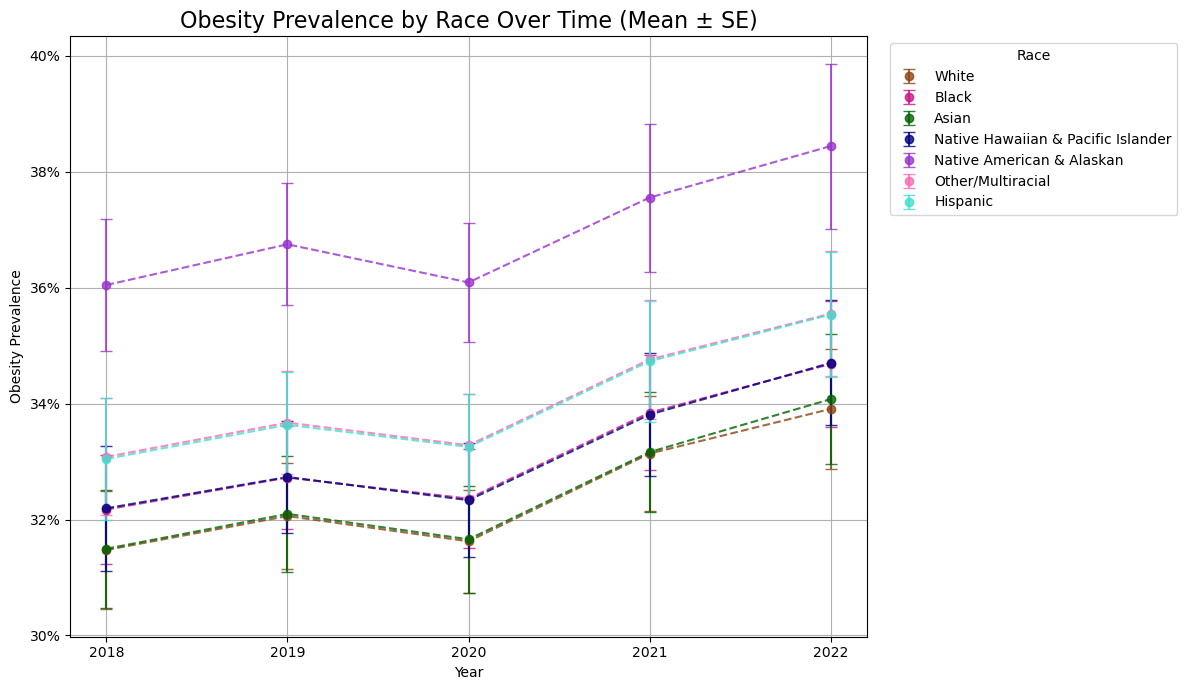

In [199]:
# Standard error plots 
from matplotlib.ticker import FuncFormatter

# Obesity
obesity_columns = {
    '%WhiteObesity': 'White',
    '%BlackObesity': 'Black',
    '%AsianObesity': 'Asian',
    '%NHOPIObesity': 'Native Hawaiian & Pacific Islander',
    '%AIANObesity': 'Native American & Alaskan',
    '%OMultirObesity': 'Other/Multiracial',
    '%HispanicObesity': 'Hispanic'
}

# Colors
colors = ['saddlebrown', 'mediumvioletred', 'darkgreen', 'navy', 'darkorchid', 'hotpink', 'turquoise']

# Extract years
years = AGG_DATA_SEM.index.values

# Start plot
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Loop through each race
for i, (col, race_label) in enumerate(obesity_columns.items()):
    mean_vals = AGG_DATA_SEM[(col, 'mean')].values
    se_vals = AGG_DATA_SEM[(col, 'std_error_mean')].values  

    ax.errorbar(
        years, mean_vals,
        yerr=se_vals,
        fmt='o', label=race_label,
        color=colors[i], capsize=4, alpha=0.8
    )
    ax.plot(years, mean_vals, color=colors[i], linestyle='--', alpha=0.8)

# Formatting
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
ax.set_xlabel("Year")
ax.set_ylabel("Obesity Prevalence")
ax.set_title("Obesity Prevalence by Race Over Time (Mean ± SE)", fontsize=16)
ax.legend(title="Race", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.show()

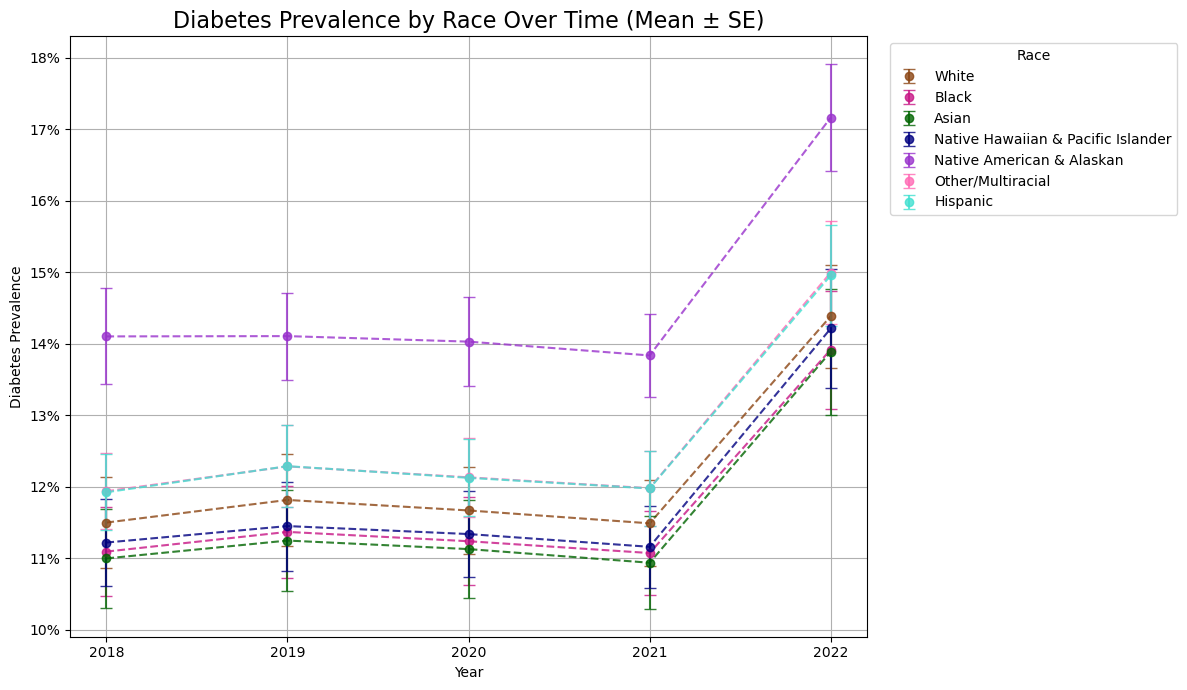

In [200]:
# Diabetes 
diabetes_columns = {
    '%WhiteDiabetes': 'White',
    '%BlackDiabetes': 'Black',
    '%AsianDiabetes': 'Asian',
    '%NHOPIDiabetes': 'Native Hawaiian & Pacific Islander',
    '%AIANDiabetes': 'Native American & Alaskan',
    '%OMultirDiabetes': 'Other/Multiracial',
    '%HispanicDiabetes': 'Hispanic'
}

# Colors 
colors = ['saddlebrown', 'mediumvioletred', 'darkgreen', 'navy', 'darkorchid', 'hotpink', 'turquoise']

# Extract years
years = AGG_DATA_SEM.index.values

# Start plot
plt.figure(figsize=(12, 7))
ax = plt.gca()

# Loop through each race
for i, (col, race_label) in enumerate(diabetes_columns.items()):
    mean_vals = AGG_DATA_SEM[(col, 'mean')].values
    se_vals = AGG_DATA_SEM[(col, 'std_error_mean')].values  

    ax.errorbar(
        years, mean_vals,
        yerr=se_vals,
        fmt='o', label=race_label,
        color=colors[i], capsize=4, alpha=0.8
    )
    ax.plot(years, mean_vals, color=colors[i], linestyle='--', alpha=0.8)

# Formatting
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y*100:.0f}%"))
ax.set_xlabel("Year")
ax.set_ylabel("Diabetes Prevalence")
ax.set_title("Diabetes Prevalence by Race Over Time (Mean ± SE)", fontsize=16)
ax.legend(title="Race", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Work with Cole's df and the food desert score from FARA to make some plots with food desert score 
 
# Define flags to sum score again
food_desert_flags = [
    "LILATracts_1And10", "LILATracts_halfAnd10", "LILATracts_1And20",
    "LILATracts_Vehicle", "LowIncomeTracts", "LATracts1", "LATracts10", "LATracts20"
]

# Get score, pull needed cols from FARA 
AZ_FARA["food_desert_score"] = AZ_FARA[food_desert_flags].sum(axis=1)
AZ_FARA_subset = AZ_FARA[["CountyName", "food_desert_score"]]

# Merge
merged_df = Unioned_Data_By_Race.merge(AZ_FARA_subset, on="CountyName", how="left")
merged_df.head()

,CountyName,year,%WhiteDiabetes,%WhiteObesity,%BlackDiabetes,%BlackObesity,%AsianDiabetes,%AsianObesity,%NHOPIDiabetes,%NHOPIObesity,%AIANDiabetes,%AIANObesity,%OMultirDiabetes,%OMultirObesity,%HispanicDiabetes,%HispanicObesity,food_desert_score
0,Apache,2018,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,7
1,Apache,2018,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,7
2,Apache,2018,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,5
3,Apache,2018,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,7
4,Apache,2018,0.111111,0.287668,0.131051,0.31804,0.148798,0.336039,0.147077,0.332077,0.177325,0.371487,0.134515,0.319048,0.122297,0.30519,2


In [ ]:
# Food desert score visual set up 
import re
from matplotlib.colors import Normalize
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import PercentFormatter
from matplotlib.cm import get_cmap

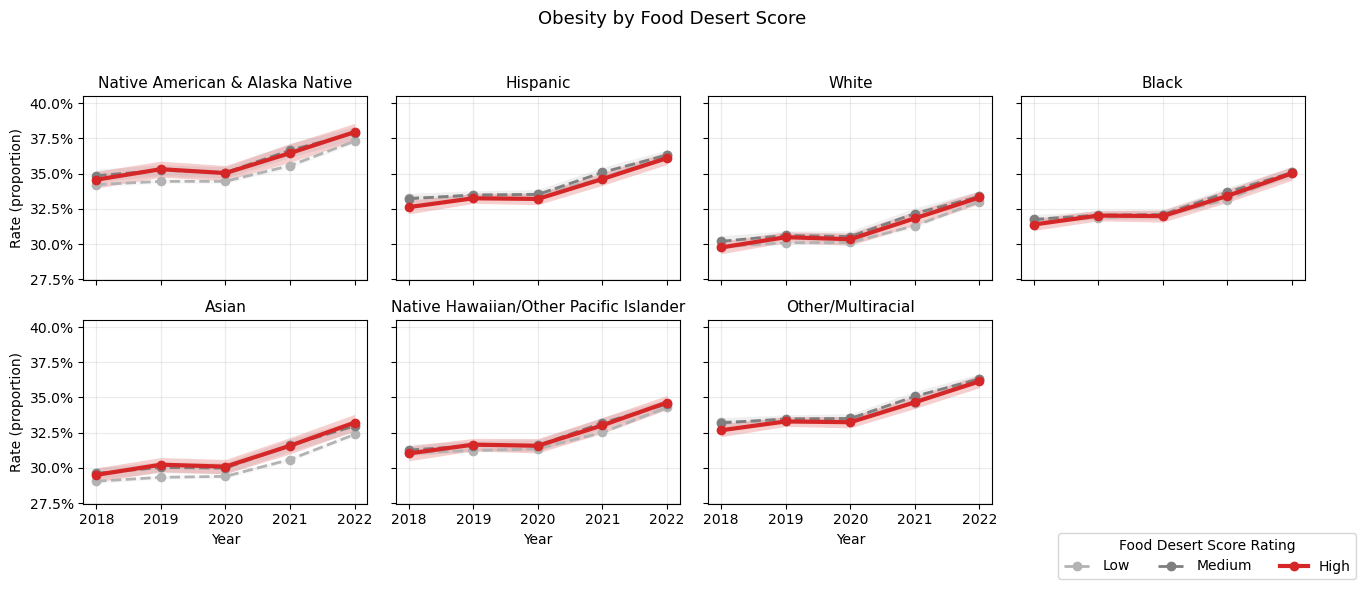

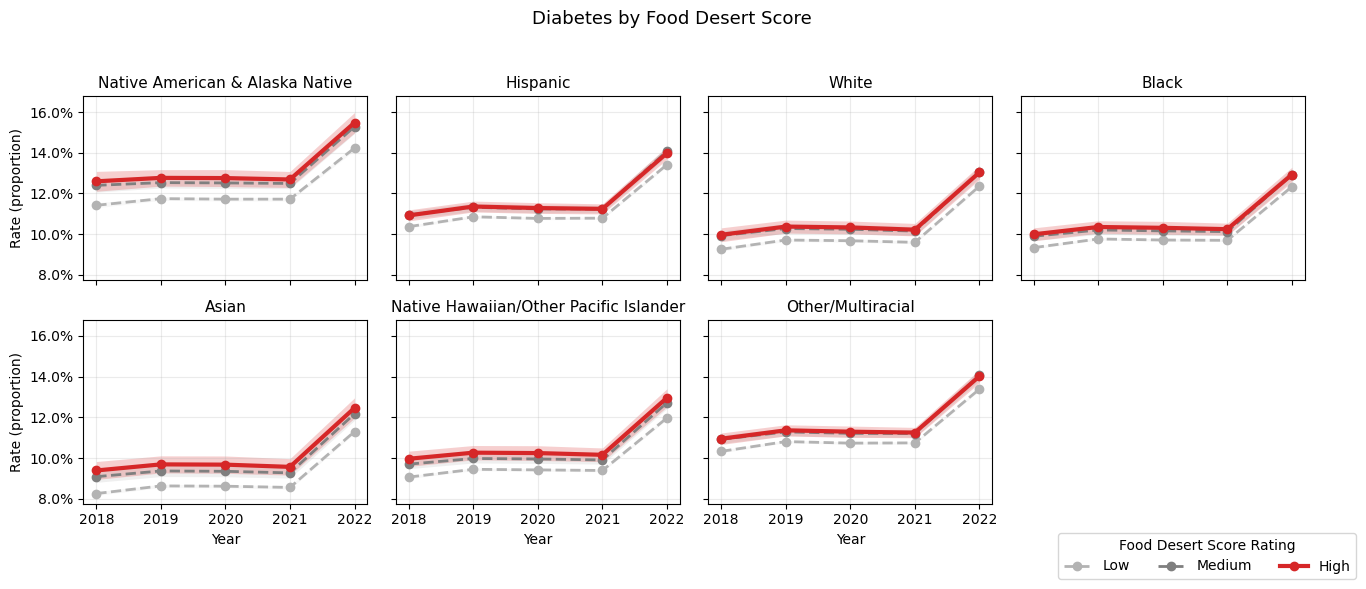

In [185]:
# Food desert vs race vs outcome 
rate_cols = [c for c in merged_df.columns if c.startswith('%') and ('Obesity' in c or 'Diabetes' in c)]
long = (
    merged_df
      .melt(id_vars=['CountyName', 'year', 'food_desert_score'],
            value_vars=rate_cols,
            var_name='Race_Outcome', value_name='rate')
      .dropna(subset=['rate', 'food_desert_score'])
      .copy()
)

long['Outcome'] = long['Race_Outcome'].str.extract(r'(Obesity|Diabetes)')
long['Race']    = long['Race_Outcome'].str.extract(r'%(\w+?)(?=Obesity|Diabetes)')

# Labels 
race_map = {
    'AIAN':'Native American & Alaska Native','White':'White','Black':'Black','Asian':'Asian',
    'NHOPI':'Native Hawaiian/Other Pacific Islander','OMultir':'Other/Multiracial','Hispanic':'Hispanic'
}
race_order = ['Native American & Alaska Native','Hispanic','White','Black','Asian',
              'Native Hawaiian/Other Pacific Islander','Other/Multiracial']
outcomes = ['Obesity','Diabetes']

long['Race'] = long['Race'].map(race_map).fillna(long['Race'])
long = long[long['Race'].isin(race_order) & long['Outcome'].isin(outcomes)].copy()
long['Race'] = pd.Categorical(long['Race'], categories=race_order, ordered=True)
long['year'] = pd.to_numeric(long['year'], errors='coerce')
long = long.dropna(subset=['food_desert_score','year']).copy()

# Manual FDS bins, low (0-2) med (3-5) high (6-7)
long['FDS_bin'] = pd.cut(
    long['food_desert_score'],
    bins=[-0.5, 2.5, 5.5, 7.5],              
    labels=['Low','Medium','High'],
    include_lowest=True
)
bin_order = ['Low','Medium','High']

# Aggregate mean + SE for 95% confidence int
def agg_for(outcome):
    d = long[long['Outcome']==outcome]
    g = (d.groupby(['Race','year','FDS_bin'], observed=True)['rate']
           .agg(['mean','std','count'])
           .rename(columns={'mean':'y','std':'sd','count':'n'})
           .reset_index())
    g['se'] = g['sd'] / np.sqrt(g['n'].clip(lower=1))
    return g

ob = agg_for('Obesity')
dm = agg_for('Diabetes')

# Plot set up 
def plot_outcome(df, outcome_title):
    races = race_order
    years_all = np.sort(df['year'].unique())

    # global y-lims 
    y_min = (df['y'] - 1.96*df['se']).min()
    y_max = (df['y'] + 1.96*df['se']).max()

    n_cols = 4
    n_rows = int(np.ceil(len(races)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.6*n_cols, 3.0*n_rows),
                             sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    # Colors & styles to show emphasis 
    bin_color = {'Low':'#B3B3B3', 'Medium': '#7F7F7F', 'High': '#D62728'}  # red for High to highlight 
    bin_style = {'Low': '--', 'Medium': '--', 'High': '-'}                  # dashed Med/Low to de-emphasize 
    bin_width = {'Low': 2, 'Medium': 2, 'High': 3}                          # thicker High line to highlight
    fill_alpha = {'Low': 0.10, 'Medium': 0.12, 'High': 0.22}

    legend_lines = {}

    for i, race in enumerate(races):
        r, c = divmod(i, n_cols)
        ax = axes[r, c]
        sub = df[df['Race'] == race].copy()
        if sub.empty:
            ax.set_visible(False)
            continue

        for b in bin_order:  # High line plotted on top 
            sb = sub[sub['FDS_bin'] == b].sort_values('year')
            if sb.empty:
                continue

            line, = ax.plot(
                sb['year'], sb['y'],
                marker='o', linewidth=bin_width[b],
                linestyle=bin_style[b], color=bin_color[b], label=b,
                zorder=3 if b == 'High' else 2
            )
            ax.fill_between(
                sb['year'],
                sb['y'] - 1.96*sb['se'],
                sb['y'] + 1.96*sb['se'],
                alpha=fill_alpha[b], color=bin_color[b], linewidth=0, zorder=1
            )

            if b not in legend_lines:
                legend_lines[b] = line

        ax.set_title(race, fontsize=11)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.grid(True, alpha=0.25)

    # hide any unused plots from final
    for j in range(i + 1, n_rows * n_cols):
        r, c = divmod(j, n_cols)
        axes[r, c].set_visible(False)

    for ax in axes[-1, :]:
        if ax.get_visible():
            ax.set_xlabel('Year')
    axes[0, 0].set_ylabel('Rate (proportion)')
    for r in range(1, n_rows):
        axes[r, 0].set_ylabel('Rate (proportion)')

    for ax in axes.ravel():
        if ax.get_visible():
            ax.set_ylim(max(0, y_min * 0.95), min(1, y_max * 1.05))
            ax.set_xticks(years_all)

    fig.suptitle(f'{outcome_title} by Food Desert Score', y=0.98, fontsize=13)

    # Legend stuff
    fig.legend(
        [legend_lines[b] for b in bin_order if b in legend_lines],
        [b for b in bin_order if b in legend_lines],
        title='Food Desert Score Rating',
        loc='lower right', bbox_to_anchor=(0.98, 0.02),
        ncol=3, frameon=True
    )

    fig.tight_layout(rect=[0.03, 0.06, 0.95, 0.95])
    plt.show()

# Visualize 
plot_outcome(ob, 'Obesity')
plot_outcome(dm, 'Diabetes')

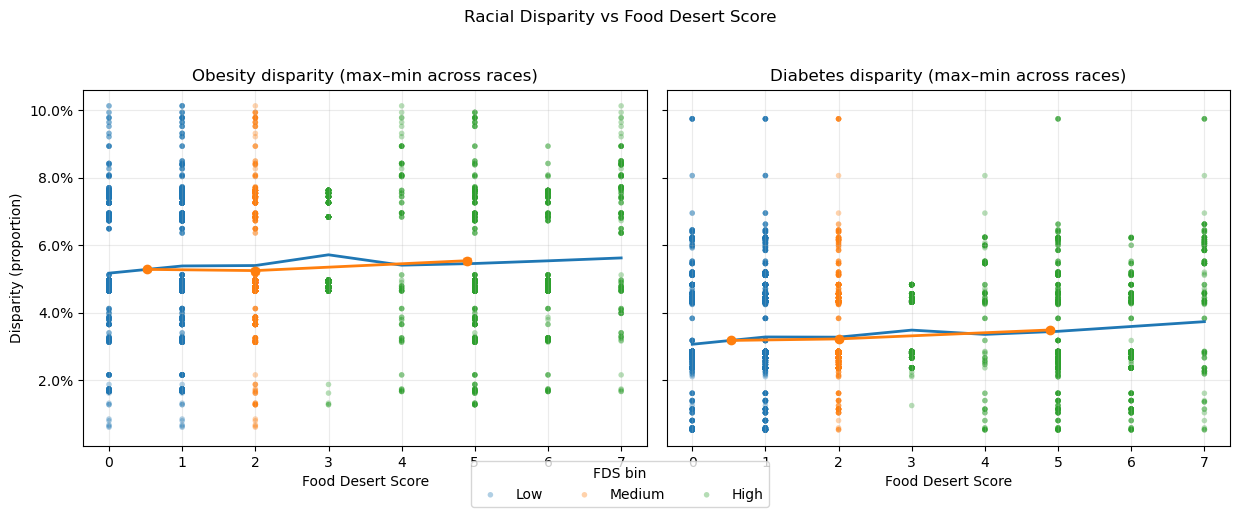

In [ ]:
# Attempting a disparity calculation/plot for food desert and race 
df = merged_df.copy()

# Build disparity columns; max - min across race columns
ob_cols = [c for c in df.columns if c.startswith('%') and c.endswith('Obesity')]
dm_cols = [c for c in df.columns if c.startswith('%') and c.endswith('Diabetes')]

if not ob_cols or not dm_cols:
    raise ValueError("Couldn't find %...Obesity or %...Diabetes columns.")

df['obesity_disparity']  = df[ob_cols].max(axis=1) - df[ob_cols].min(axis=1)
df['diabetes_disparity'] = df[dm_cols].max(axis=1) - df[dm_cols].min(axis=1)

# Keep valid rows, create bins for food des score
df = df.dropna(subset=['food_desert_score', 'obesity_disparity', 'diabetes_disparity']).copy()
df['fds_bin'] = pd.qcut(df['food_desert_score'], q=3,
                        labels=['Low','Medium','High'], duplicates='drop')

# Bin summaries for mean lines + 95% confidence int
def bin_summary(ycol):
    g = df.groupby('fds_bin', observed=True).agg(
        mean_y=(ycol, 'mean'),
        std_y=(ycol, 'std'),
        n=('food_desert_score', 'size'),
        x_mean=('food_desert_score', 'mean')
    ).reset_index()
    g['se'] = g['std_y'] / np.sqrt(g['n'].clip(lower=1))
    return g

ob_sum = bin_summary('obesity_disparity')
dm_sum = bin_summary('diabetes_disparity')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)

def panel(ax, ycol, title, summary):
    # Scatter points colored by bins 
    for label, sub in df.groupby('fds_bin', observed=True):
        ax.scatter(sub['food_desert_score'], sub[ycol],
                   s=16, alpha=0.35, label=str(label), edgecolors='none')

    # LOWESS 
    m = np.isfinite(df['food_desert_score']) & np.isfinite(df[ycol])
    if m.sum() >= 8:
        xs = df.loc[m, 'food_desert_score'].to_numpy()
        ys = df.loc[m, ycol].to_numpy()
        order = np.argsort(xs)
        lo = lowess(ys[order], xs[order], frac=0.6, it=0, return_sorted=True)
        ax.plot(lo[:,0], lo[:,1], linewidth=2)

    # Bin means + 95% CI 
    ax.errorbar(summary['x_mean'], summary['mean_y'],
                yerr=1.96*summary['se'], fmt='-o', linewidth=2, capsize=3)

    ax.set_title(title)
    ax.set_xlabel('Food Desert Score')
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0)) 

panel(axes[0], 'obesity_disparity',  'Obesity disparity (max–min across races)', ob_sum)
panel(axes[1], 'diabetes_disparity', 'Diabetes disparity (max–min across races)', dm_sum)

axes[0].set_ylabel('Disparity (proportion)')

# Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='FDS bin', loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))

fig.suptitle('Racial Disparity vs Food Desert Score',
             y=1.03, fontsize=12)
plt.tight_layout()
plt.show()